# Full Pair Comparison

Runs 81 total variants across the three requested pair-comparison cases. Each case sweeps scenarios 1-3, robust epsilon starts `0.25`, `0.5`, `1.0`, and epsilon schedules `linear`, `exponential`, `constant`.

In [1]:
from pathlib import Path
import dataclasses
import sys

notebook_dir = Path.cwd()
if notebook_dir.name != "bimatrix_game":
    candidate = notebook_dir / "discrete_action_space" / "bimatrix_game"
    if candidate.exists():
        notebook_dir = candidate.resolve()

for path in (notebook_dir, notebook_dir.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    DEEP_SRQ_HYPERPARAMS,
    SCENARIO_CONFIGS,
    configure_path_runtime,
    save_training_stats,
    train_pairing,
)
from stats_utils import load_training_stats

discrete_action_space_dir = notebook_dir.parent
pathwrap_path = Path(configure_path_runtime(discrete_action_space_dir)).resolve()
if not pathwrap_path.exists():
    raise FileNotFoundError(f"PATH solver library not found at {pathwrap_path}")


In [2]:
def run_pair_epsilon_sweep(
    *,
    pairing,
    case_slug,
    case_seed_offset,
    scenarios,
    scenario_configs,
    epsilon_starts,
    epsilon_schedules,
    n_episodes,
    base_seed,
    output_root,
    use_gpu,
    write_plots,
    base_hyperparameters,
    hyperparameter_overrides,
):
    results = {}
    case_output_root = Path(output_root) / case_slug

    def variant_stats_path(scenario_key, epsilon_start, epsilon_schedule, variant_key, seed):
        run_slug_parts = []
        for algorithm in pairing:
            if algorithm == "nashq":
                run_slug_parts.append("nashq")
            else:
                run_slug_parts.append(
                    f"{algorithm}_{epsilon_schedule}_eps{float(epsilon_start):g}"
                )
        run_slug = "_vs_".join(run_slug_parts)
        run_slug = f"{run_slug}_{variant_key}_{seed}"
        return case_output_root / scenario_key / run_slug / "training_stats.txt"

    for scenario_index, scenario_key in enumerate(scenarios):
        scenario_config = scenario_configs[scenario_key]
        scenario_results = {}

        for schedule_index, epsilon_schedule in enumerate(epsilon_schedules):
            for epsilon_index, epsilon_start in enumerate(epsilon_starts):
                seed = (
                    base_seed
                    + case_seed_offset
                    + scenario_index * 1000
                    + schedule_index * 100
                    + epsilon_index
                )
                variant_key = f"eps{epsilon_start:g}_{epsilon_schedule}"
                hyperparameters = dataclasses.replace(
                    base_hyperparameters,
                    **hyperparameter_overrides,
                    epsilon_robust=float(epsilon_start),
                    epsilon_robust_initial=float(epsilon_start),
                    epsilon_schedule=epsilon_schedule,
                )
                epsilon_robust_initials = tuple(
                    None if algorithm == "nashq" else float(epsilon_start)
                    for algorithm in pairing
                )
                per_agent_schedules = tuple(
                    None if algorithm == "nashq" else epsilon_schedule
                    for algorithm in pairing
                )

                stats_path = variant_stats_path(
                    scenario_key,
                    epsilon_start,
                    epsilon_schedule,
                    variant_key,
                    seed,
                )
                if stats_path.exists():
                    stats = load_training_stats(stats_path)
                    print(f"Skipping existing run: {stats_path}")
                else:
                    stats = train_pairing(
                        scenario_key=scenario_key,
                        scenario_config=scenario_config,
                        pairing=pairing,
                        n_episodes=n_episodes,
                        seed=seed,
                        output_root=case_output_root,
                        use_gpu=use_gpu,
                        write_plots=write_plots,
                        hyperparameters=hyperparameters,
                        epsilon_robust_initials=epsilon_robust_initials,
                        epsilon_schedules=per_agent_schedules,
                        run_name_suffix=variant_key,
                        include_episode_durations=False,
                        print_full_stats=False,
                    )
                stats["case_slug"] = case_slug
                stats["variant_key"] = variant_key
                stats["case_seed_offset"] = int(case_seed_offset)
                scenario_results[variant_key] = stats

        results[scenario_key] = scenario_results

    return results


In [3]:
scenarios = ("scenario1", "scenario2", "scenario3")
epsilon_starts = (0.25, 0.5, 1.0)
epsilon_schedules = ("linear", "exponential", "constant")

solver_name = "path_c_pool"
network_type = "joint_output"
n_episodes = 3000
batch_size = 16
target_update = 100
use_gpu = True
write_plots = True

scenario_configs = SCENARIO_CONFIGS
base_hyperparameters = DEEP_SRQ_HYPERPARAMS

# Applied only to Deep SRQ agents. Tabular SRQ/NashQ use their own configs.
deep_srq_hyperparameter_overrides = {
    "batch_size": batch_size,
    "target_update_steps": target_update,
    "sre_solver_name": solver_name,
    "sre_num_repeats": 5,
    "sre_include_pure_starts": True,
    "network_type": network_type,
    "sre_solver_workers": 8,
    "sre_solver_start_method": None,
}

full_pair_output_root = Path("full_pair_comparison_runs")

common_sweep_kwargs = {
    "scenarios": scenarios,
    "scenario_configs": scenario_configs,
    "epsilon_starts": epsilon_starts,
    "epsilon_schedules": epsilon_schedules,
    "n_episodes": n_episodes,
    "base_seed": BASE_SEED,
    "output_root": full_pair_output_root,
    "use_gpu": use_gpu,
    "write_plots": write_plots,
    "base_hyperparameters": base_hyperparameters,
    "hyperparameter_overrides": deep_srq_hyperparameter_overrides,
}


## Deep SRQ vs Deep SRQ

Training DeepSRQ vs DeepSRQ on Scenario 1 for 3000 episodes | seed=2025.


scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:16<00:00,  1.42it/s] 


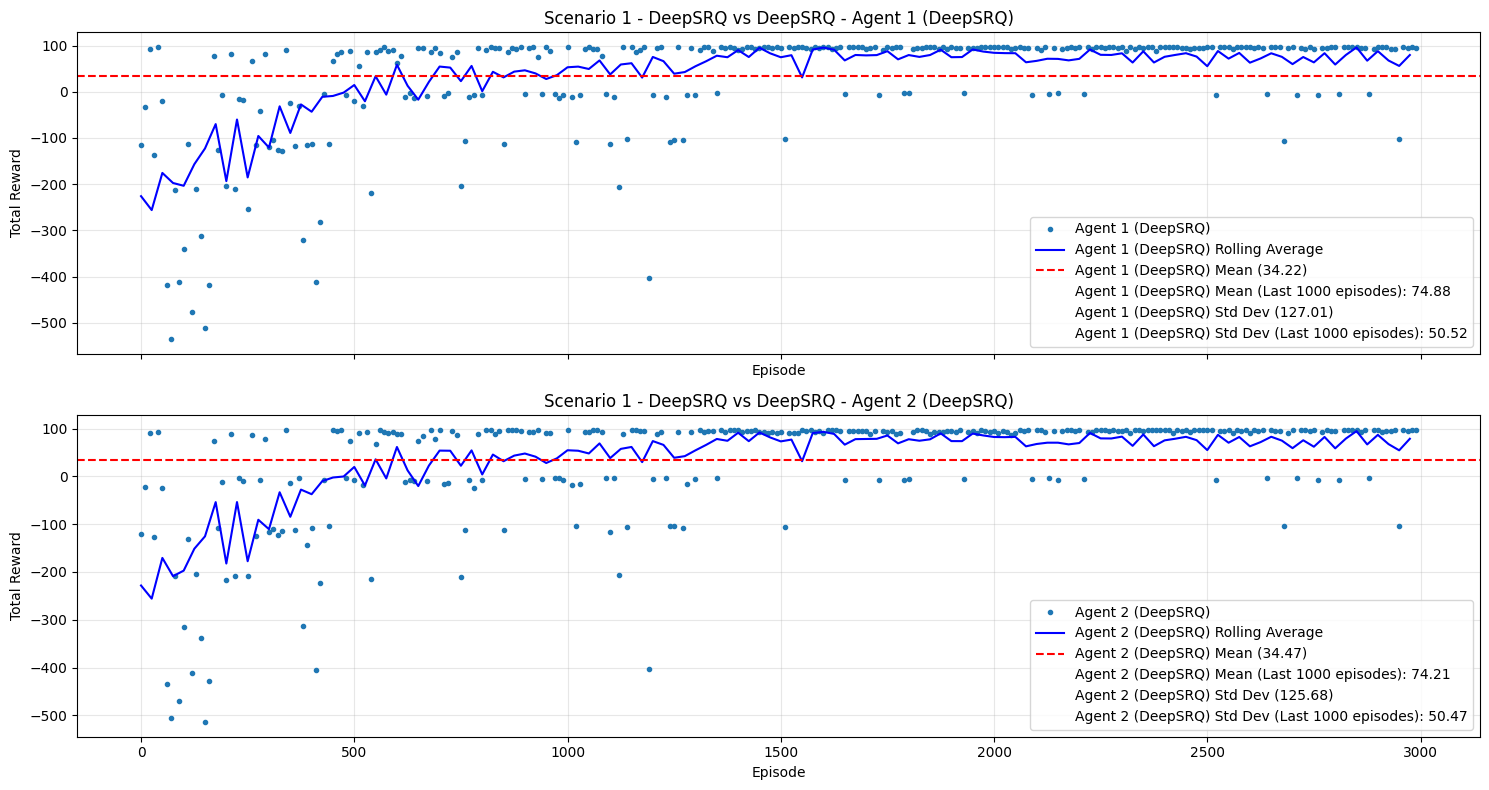

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_2025/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_2025
Wall clock: 2116.188s (35.27 min)
Episode time:   count=3000, mean=0.704664s (704663.62 us), min=0.000660s, max=5.572823s, std=0.532510s
SRE solve time: count=523975, mean=0.003345s (3345.30 us), min=0.001448s, max=0.211011s, std=0.003020s
Backend solve:  count=523975, mean=0.014033s (14033.18 us), min=0.007093s, max=0.279822s, std=0.005272s
  Agent 0 (deep_srq)
    SRE solve:  count=523975, mean=0.003345s (3345.30 us), min=0.001448s, max=0.211011s, std=0.003020s
    Backend:    count=523975, mean=0.014033s (14033.18 us), min=0.007093s, max=0.279822s, std=0.005272s
    Update:     count=37295, mean=0.040837s (40837.35 us), min=0.019574s, max=1.129099s, std=0.010704s

Reward Summary
Scenario   | Pair               | Agent   

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [36:23<00:00,  1.37it/s] 


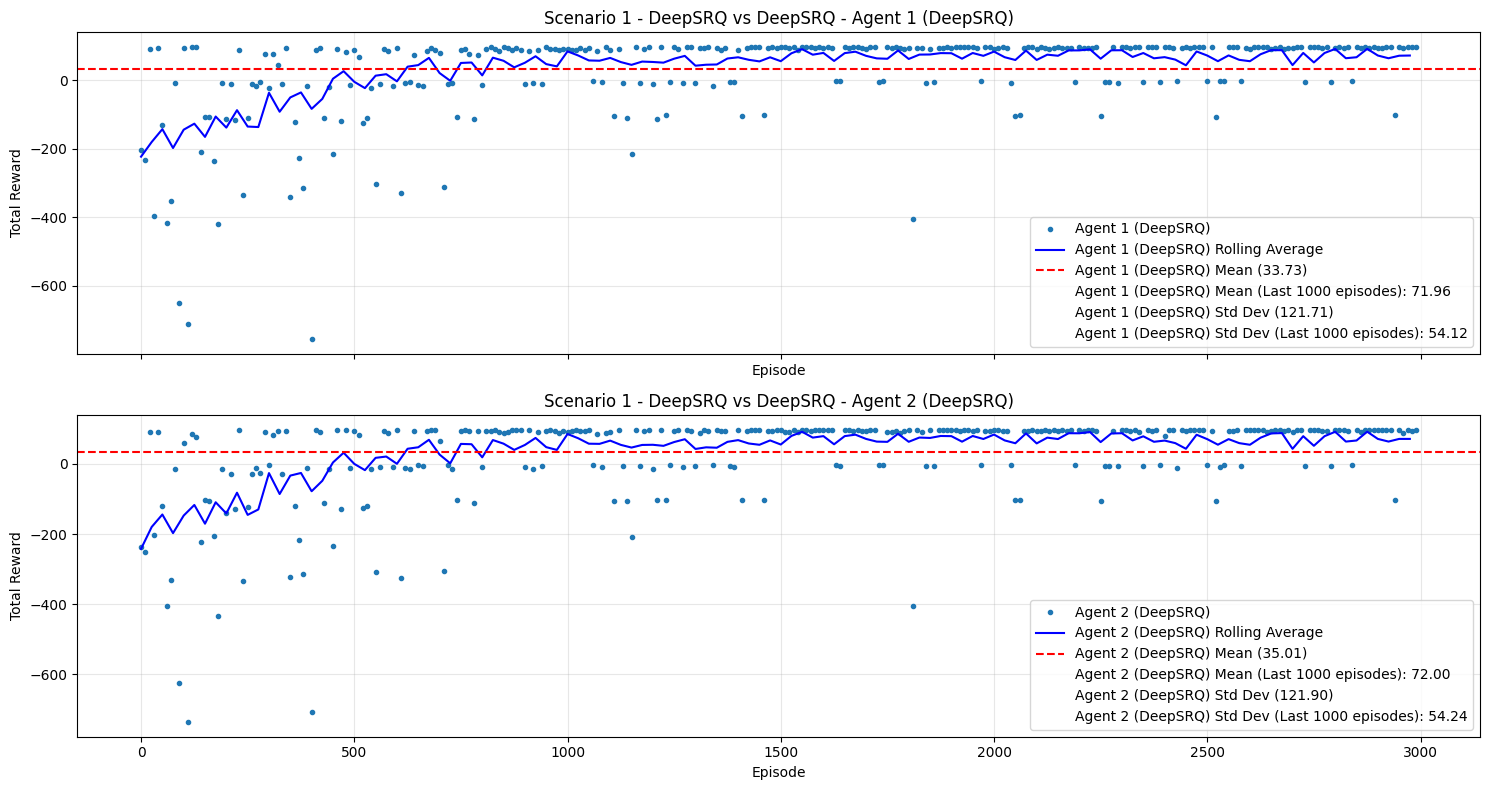

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_2026/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_2026
Wall clock: 2183.494s (36.39 min)
Episode time:   count=3000, mean=0.727087s (727087.32 us), min=0.000294s, max=10.731379s, std=0.719427s
SRE solve time: count=516267, mean=0.003533s (3532.92 us), min=0.001406s, max=0.158963s, std=0.003120s
Backend solve:  count=516267, mean=0.014892s (14892.37 us), min=0.007216s, max=1.114407s, std=0.006875s
  Agent 0 (deep_srq)
    SRE solve:  count=516267, mean=0.003533s (3532.92 us), min=0.001406s, max=0.158963s, std=0.003120s
    Backend:    count=516267, mean=0.014892s (14892.37 us), min=0.007216s, max=1.114407s, std=0.006875s
    Update:     count=37192, mean=0.042895s (42895.20 us), min=0.020698s, max=1.134325s, std=0.017740s

Reward Summary
Scenario   | Pair               | Agent        

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:51<00:00,  1.39it/s] 


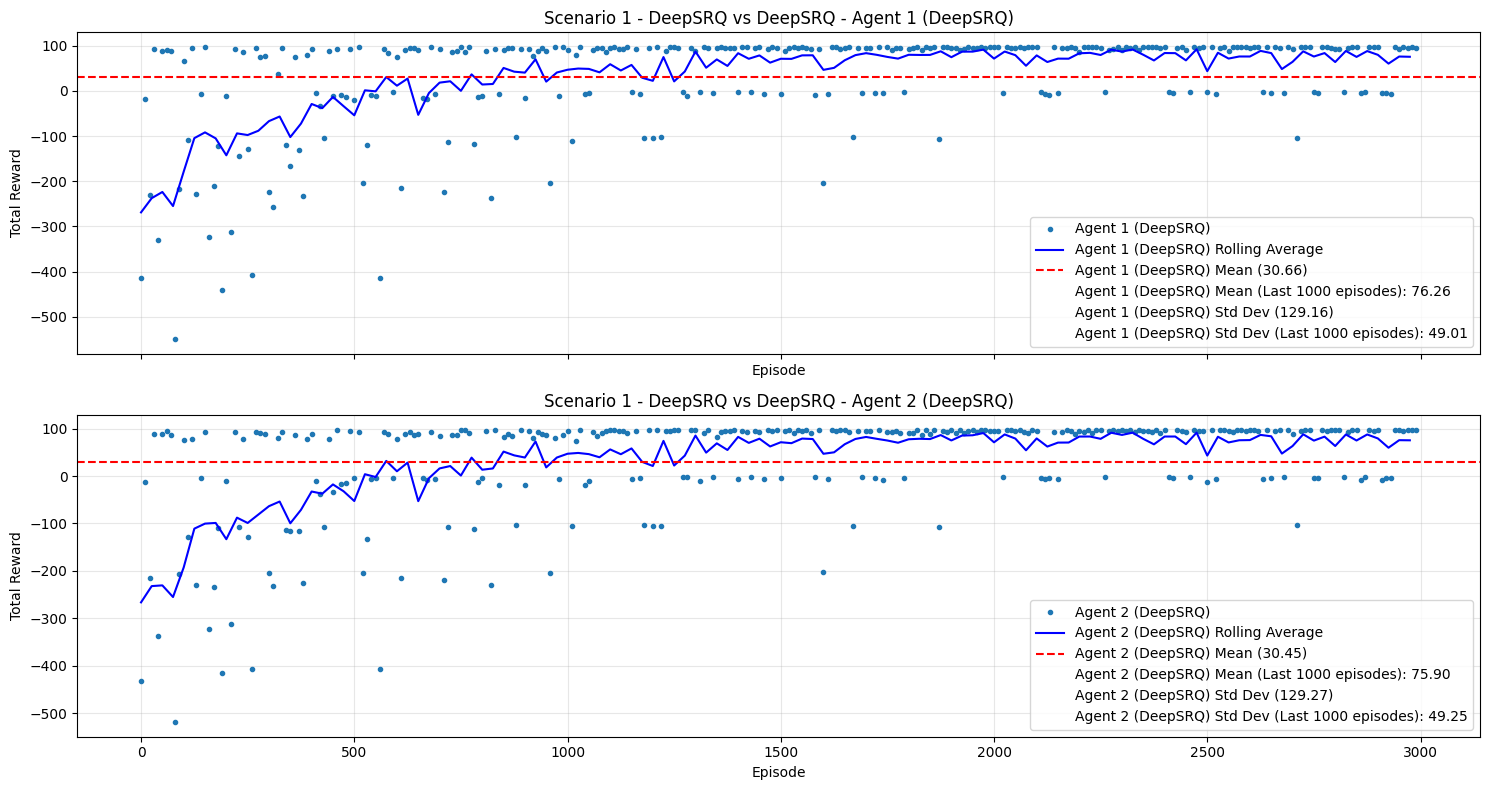

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_2027/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_2027
Wall clock: 2151.248s (35.85 min)
Episode time:   count=3000, mean=0.716379s (716378.81 us), min=0.000379s, max=5.609656s, std=0.573730s
SRE solve time: count=544681, mean=0.003306s (3306.30 us), min=0.001345s, max=0.318808s, std=0.003038s
Backend solve:  count=544681, mean=0.013757s (13757.43 us), min=0.007167s, max=0.725107s, std=0.005437s
  Agent 0 (deep_srq)
    SRE solve:  count=544681, mean=0.003306s (3306.30 us), min=0.001345s, max=0.318808s, std=0.003038s
    Backend:    count=544681, mean=0.013757s (13757.43 us), min=0.007167s, max=0.725107s, std=0.005437s
    Update:     count=38514, mean=0.040189s (40188.70 us), min=0.020448s, max=0.733315s, std=0.009862s

Reward Summary
Scenario   | Pair               | Agent             | Mean  

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:16<00:00,  1.42it/s] 


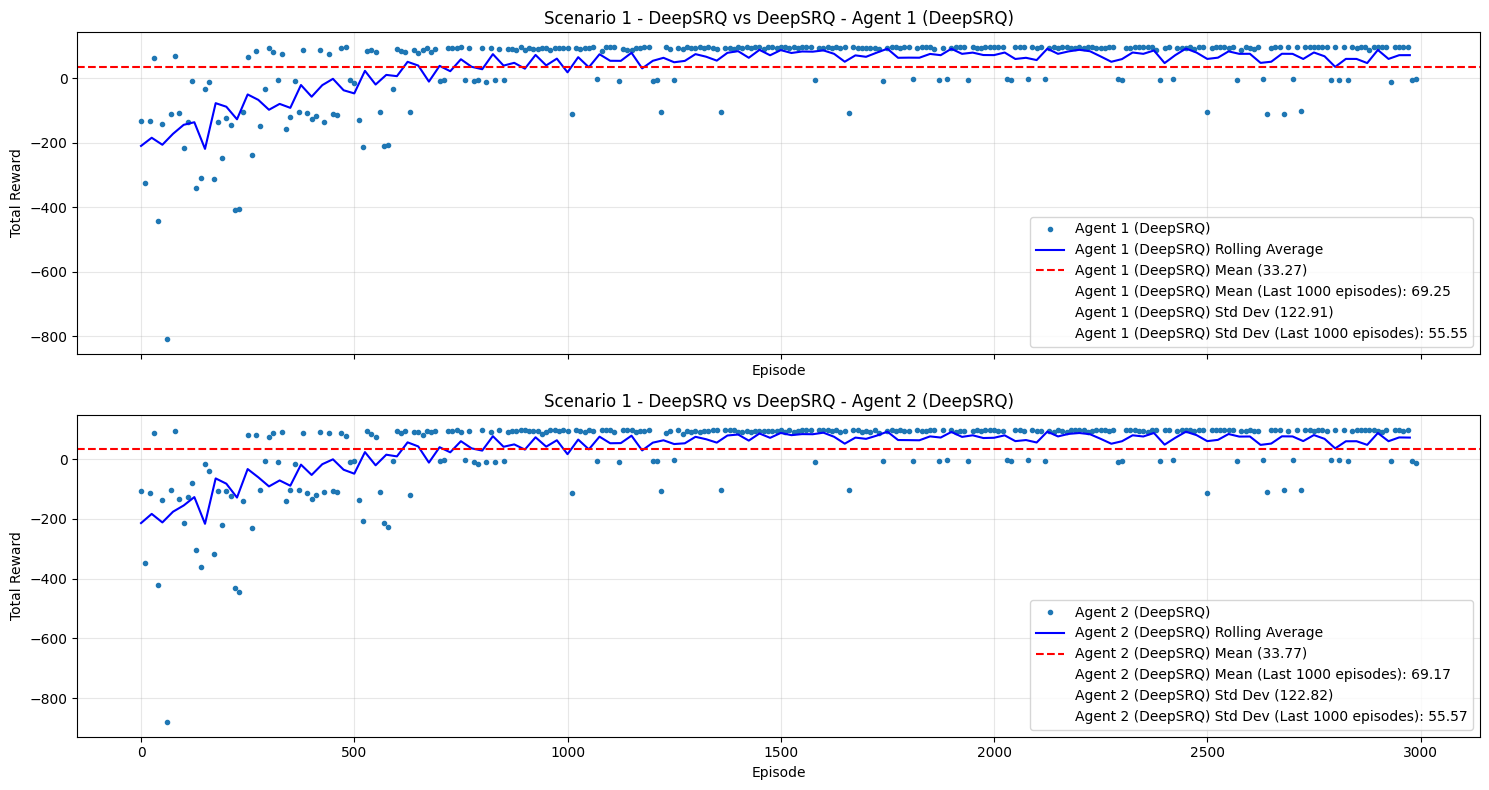

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_2125/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_2125
Wall clock: 2116.846s (35.28 min)
Episode time:   count=3000, mean=0.704921s (704921.09 us), min=0.000503s, max=5.180306s, std=0.557643s
SRE solve time: count=511361, mean=0.003528s (3528.48 us), min=0.001498s, max=0.152248s, std=0.003060s
Backend solve:  count=511361, mean=0.014767s (14766.94 us), min=0.007348s, max=0.281551s, std=0.005743s
  Agent 0 (deep_srq)
    SRE solve:  count=511361, mean=0.003528s (3528.48 us), min=0.001498s, max=0.152248s, std=0.003060s
    Backend:    count=511361, mean=0.014767s (14766.94 us), min=0.007348s, max=0.281551s, std=0.005743s
    Update:     count=36494, mean=0.042198s (42197.95 us), min=0.020469s, max=0.303070s, std=0.010012s

Reward Summary
Scenario   |

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:58<00:00,  1.39it/s] 


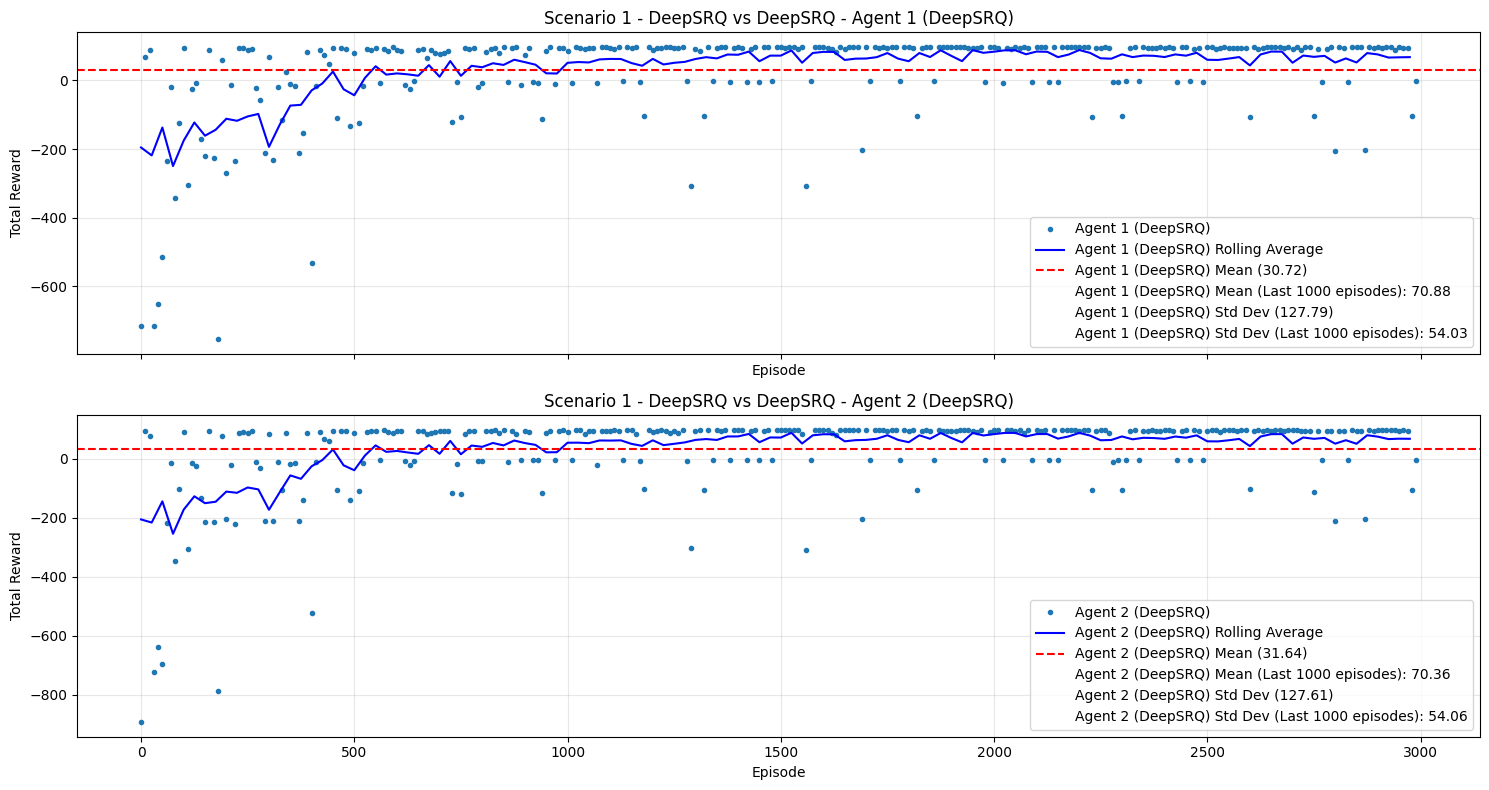

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_2126/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_2126
Wall clock: 2158.151s (35.97 min)
Episode time:   count=3000, mean=0.718684s (718684.18 us), min=0.000349s, max=5.476535s, std=0.611739s
SRE solve time: count=529631, mean=0.003464s (3463.61 us), min=0.001459s, max=0.111276s, std=0.002933s
Backend solve:  count=529631, mean=0.014634s (14634.03 us), min=0.007194s, max=0.311509s, std=0.005665s
  Agent 0 (deep_srq)
    SRE solve:  count=529631, mean=0.003464s (3463.61 us), min=0.001459s, max=0.111276s, std=0.002933s
    Backend:    count=529631, mean=0.014634s (14634.03 us), min=0.007194s, max=0.311509s, std=0.005665s
    Update:     count=38100, mean=0.041315s (41315.27 us), min=0.019347s, max=0.530517s, std=0.009942s

Reward Summary
Scenario   | Pair 

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:17<00:00,  1.42it/s] 


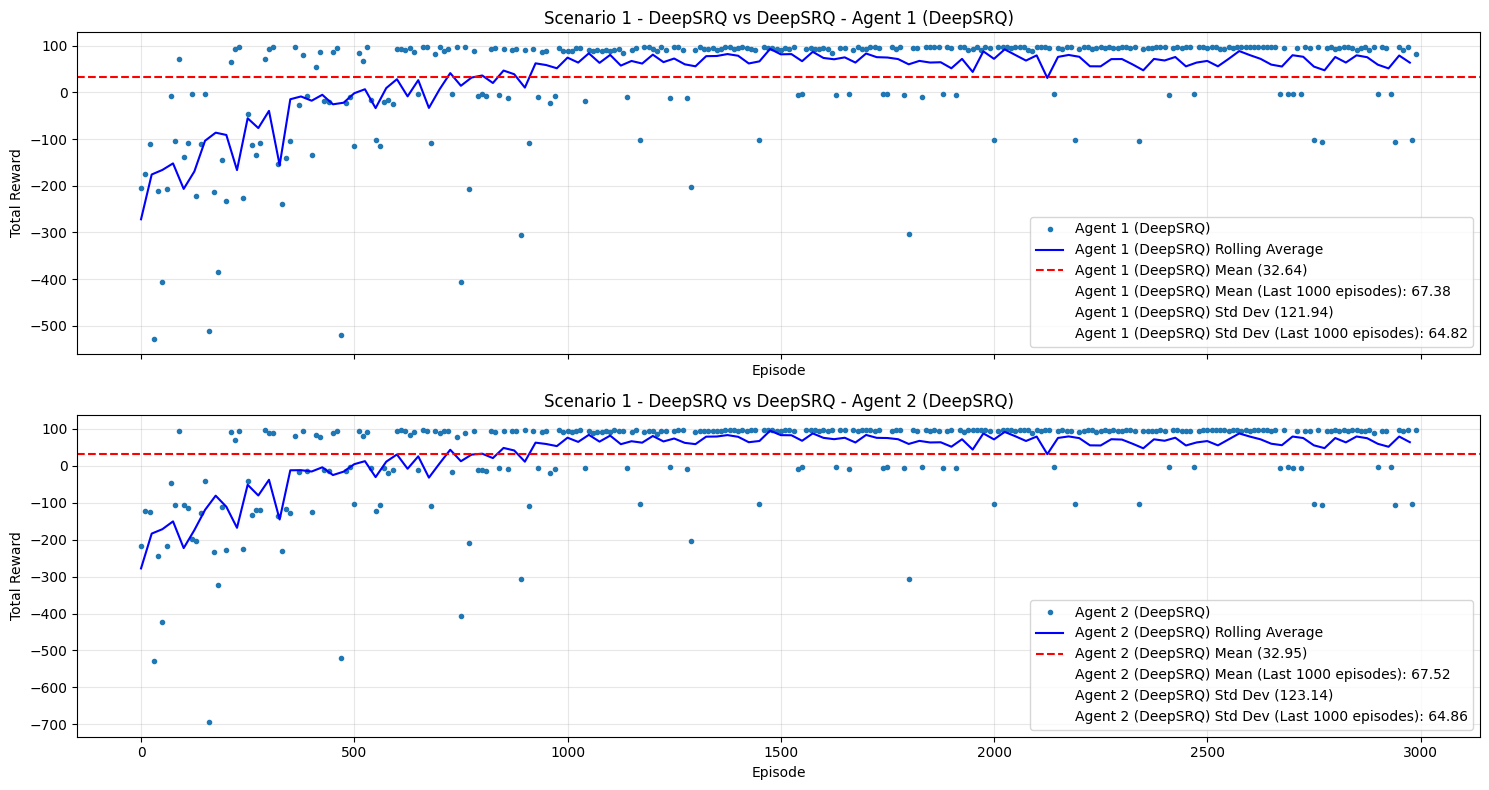

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_eps1_exponential_2127/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_eps1_exponential_2127
Wall clock: 2113.123s (35.22 min)
Episode time:   count=3000, mean=0.703658s (703658.32 us), min=0.001675s, max=5.415079s, std=0.568227s
SRE solve time: count=528004, mean=0.003396s (3396.32 us), min=0.001513s, max=0.238863s, std=0.002943s
Backend solve:  count=528004, mean=0.014349s (14349.21 us), min=0.006973s, max=0.284937s, std=0.005532s
  Agent 0 (deep_srq)
    SRE solve:  count=528004, mean=0.003396s (3396.32 us), min=0.001513s, max=0.238863s, std=0.002943s
    Backend:    count=528004, mean=0.014349s (14349.21 us), min=0.006973s, max=0.284937s, std=0.005532s
    Update:     count=37760, mean=0.040713s (40712.58 us), min=0.019824s, max=0.307239s, std=0.009445s

Reward Summary
Scenario   | Pair             

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [34:03<00:00,  1.47it/s] 


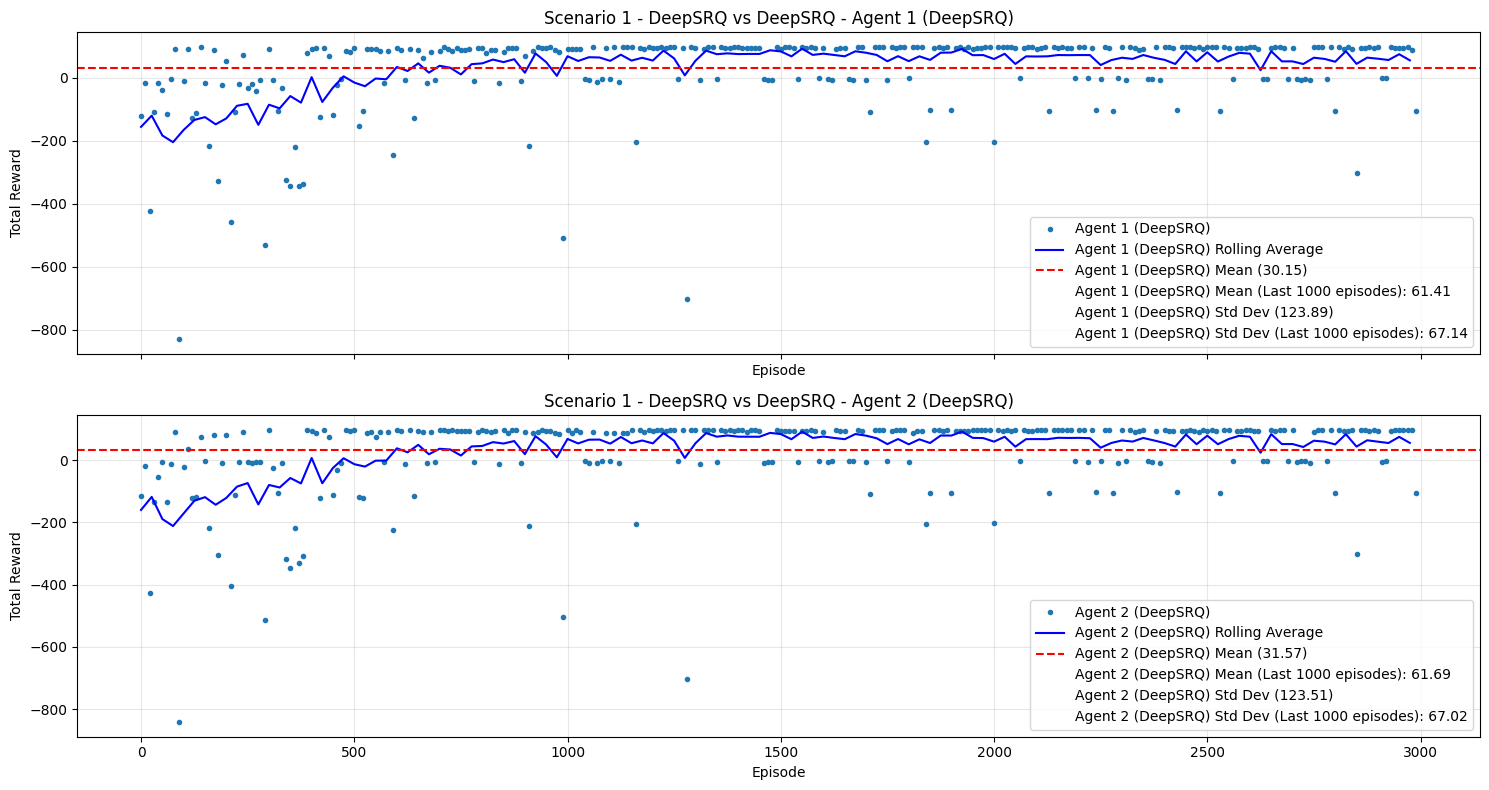

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_constant_eps0.25_vs_deep_srq_constant_eps0.25_eps0.25_constant_2225/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps0.25_vs_deep_srq_constant_eps0.25_eps0.25_constant_2225
Wall clock: 2011.698s (33.53 min)
Episode time:   count=3000, mean=0.669889s (669889.43 us), min=0.000150s, max=4.951718s, std=0.504660s
SRE solve time: count=512952, mean=0.003318s (3317.62 us), min=0.001530s, max=0.153933s, std=0.002919s
Backend solve:  count=512952, mean=0.013929s (13929.33 us), min=0.007123s, max=0.271525s, std=0.005113s
  Agent 0 (deep_srq)
    SRE solve:  count=512952, mean=0.003318s (3317.62 us), min=0.001530s, max=0.153933s, std=0.002919s
    Backend:    count=512952, mean=0.013929s (13929.33 us), min=0.007123s, max=0.271525s, std=0.005113s
    Update:     count=36853, mean=0.039242s (39241.62 us), min=0.019805s, max=0.291694s, std=0.009417s

Reward Summary
Scenario   | Pair             

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:56<00:00,  1.39it/s] 


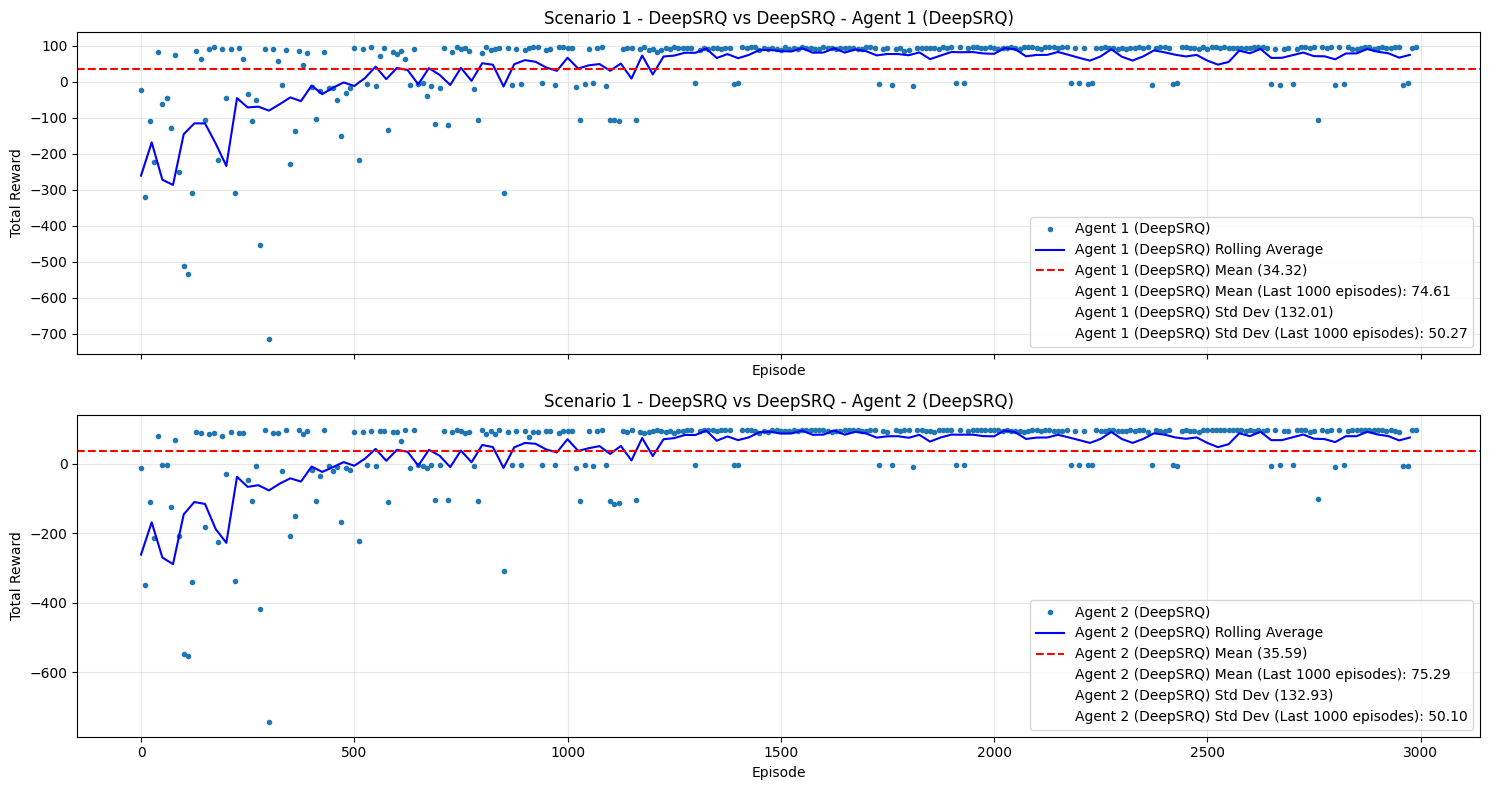

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_constant_eps0.5_vs_deep_srq_constant_eps0.5_eps0.5_constant_2226/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps0.5_vs_deep_srq_constant_eps0.5_eps0.5_constant_2226
Wall clock: 2115.956s (35.27 min)
Episode time:   count=3000, mean=0.704629s (704628.65 us), min=0.000340s, max=5.588784s, std=0.573456s
SRE solve time: count=538235, mean=0.003329s (3328.67 us), min=0.001473s, max=0.145340s, std=0.002846s
Backend solve:  count=538235, mean=0.014125s (14124.94 us), min=0.006870s, max=0.286307s, std=0.005321s
  Agent 0 (deep_srq)
    SRE solve:  count=538235, mean=0.003329s (3328.67 us), min=0.001473s, max=0.145340s, std=0.002846s
    Backend:    count=538235, mean=0.014125s (14124.94 us), min=0.006870s, max=0.286307s, std=0.005321s
    Update:     count=38687, mean=0.039691s (39691.27 us), min=0.018423s, max=0.304758s, std=0.008763s

Reward Summary
Scenario   | Pair               | Ag

scenario1: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:55<00:00,  1.39it/s] 


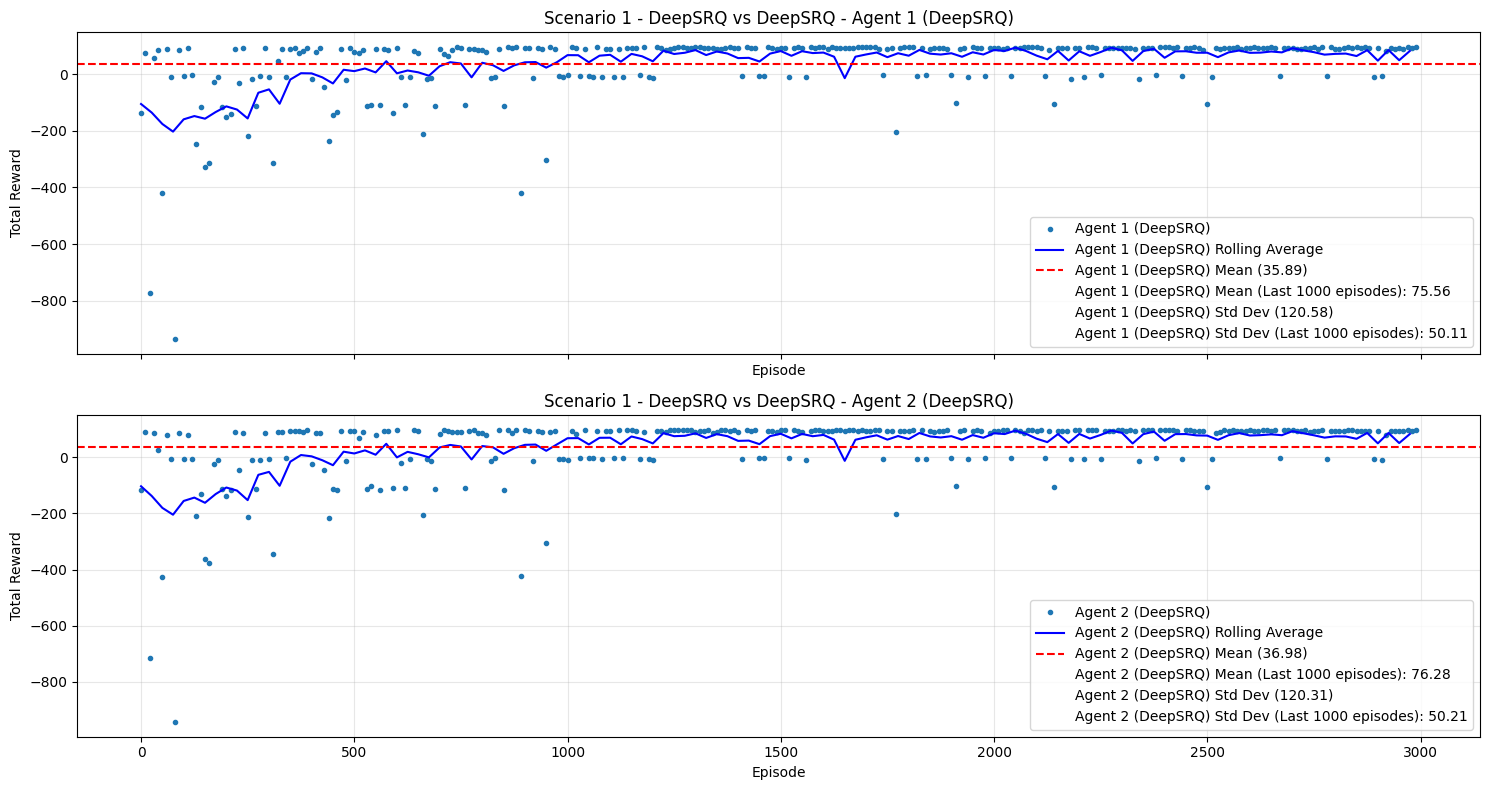

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_constant_eps1_vs_deep_srq_constant_eps1_eps1_constant_2227/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps1_vs_deep_srq_constant_eps1_eps1_constant_2227
Wall clock: 2109.540s (35.16 min)
Episode time:   count=3000, mean=0.702516s (702516.18 us), min=0.000250s, max=5.448909s, std=0.507733s
SRE solve time: count=554906, mean=0.003204s (3204.18 us), min=0.001350s, max=0.067130s, std=0.002803s
Backend solve:  count=554906, mean=0.013472s (13472.39 us), min=0.006974s, max=0.376395s, std=0.004920s
  Agent 0 (deep_srq)
    SRE solve:  count=554906, mean=0.003204s (3204.18 us), min=0.001350s, max=0.067130s, std=0.002803s
    Backend:    count=554906, mean=0.013472s (13472.39 us), min=0.006974s, max=0.376395s, std=0.004920s
    Update:     count=39418, mean=0.038197s (38197.35 us), min=0.015936s, max=0.382630s, std=0.008762s

Reward Summary
Scenario   | Pair               | Agent         

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:41<00:00,  1.40it/s] 


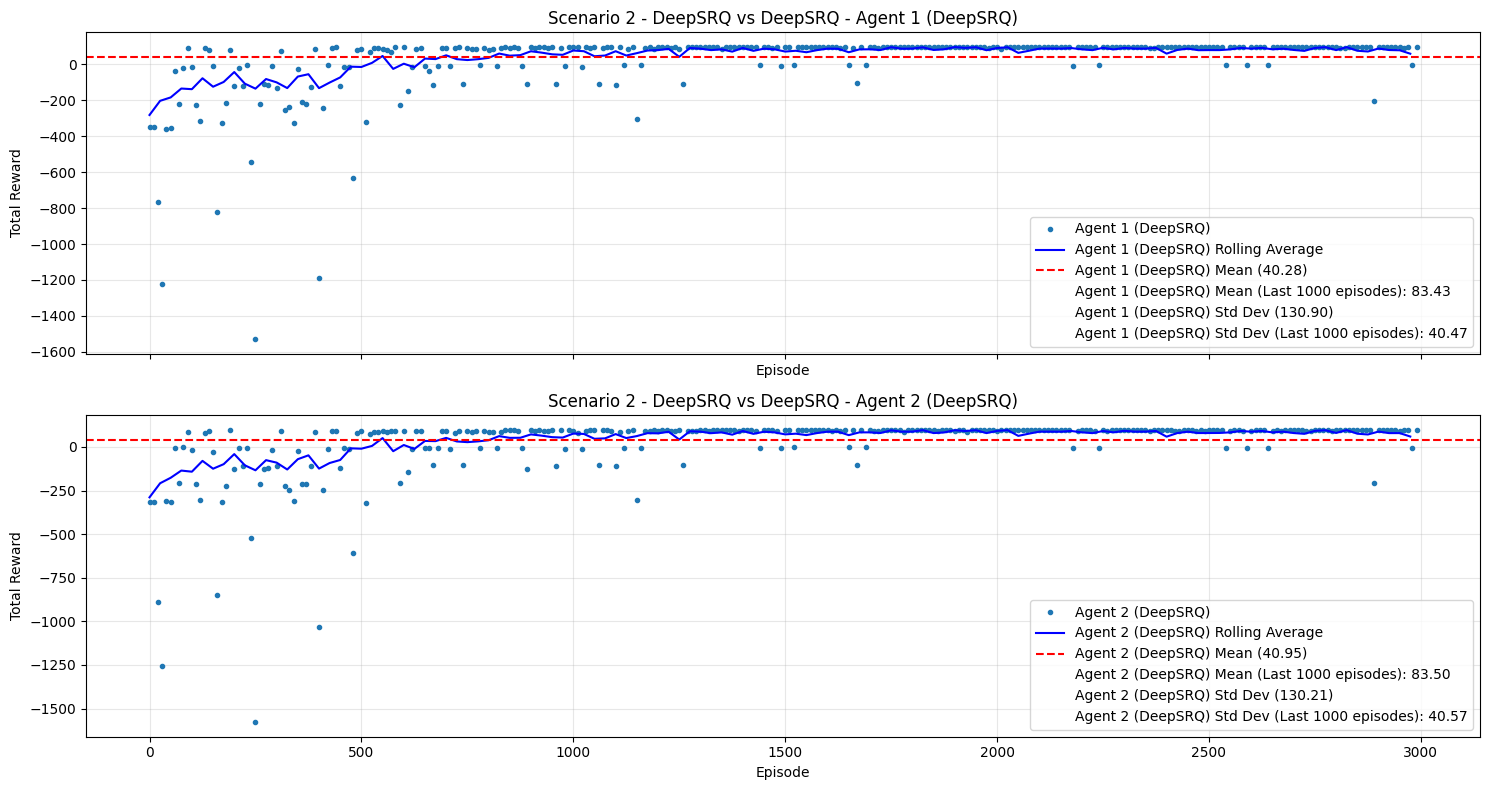

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_3025/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_3025
Wall clock: 2095.807s (34.93 min)
Episode time:   count=3000, mean=0.697922s (697922.10 us), min=0.000534s, max=5.149626s, std=0.589093s
SRE solve time: count=519875, mean=0.003448s (3448.08 us), min=0.001430s, max=0.090549s, std=0.003130s
Backend solve:  count=519875, mean=0.014746s (14745.51 us), min=0.007309s, max=0.282414s, std=0.005541s
  Agent 0 (deep_srq)
    SRE solve:  count=519875, mean=0.003448s (3448.08 us), min=0.001430s, max=0.090549s, std=0.003130s
    Backend:    count=519875, mean=0.014746s (14745.51 us), min=0.007309s, max=0.282414s, std=0.005541s
    Update:     count=36235, mean=0.041938s (41938.48 us), min=0.020182s, max=0.287999s, std=0.009879s

Reward Summary
Scenario   | Pair               | Agent   

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [34:17<00:00,  1.46it/s] 


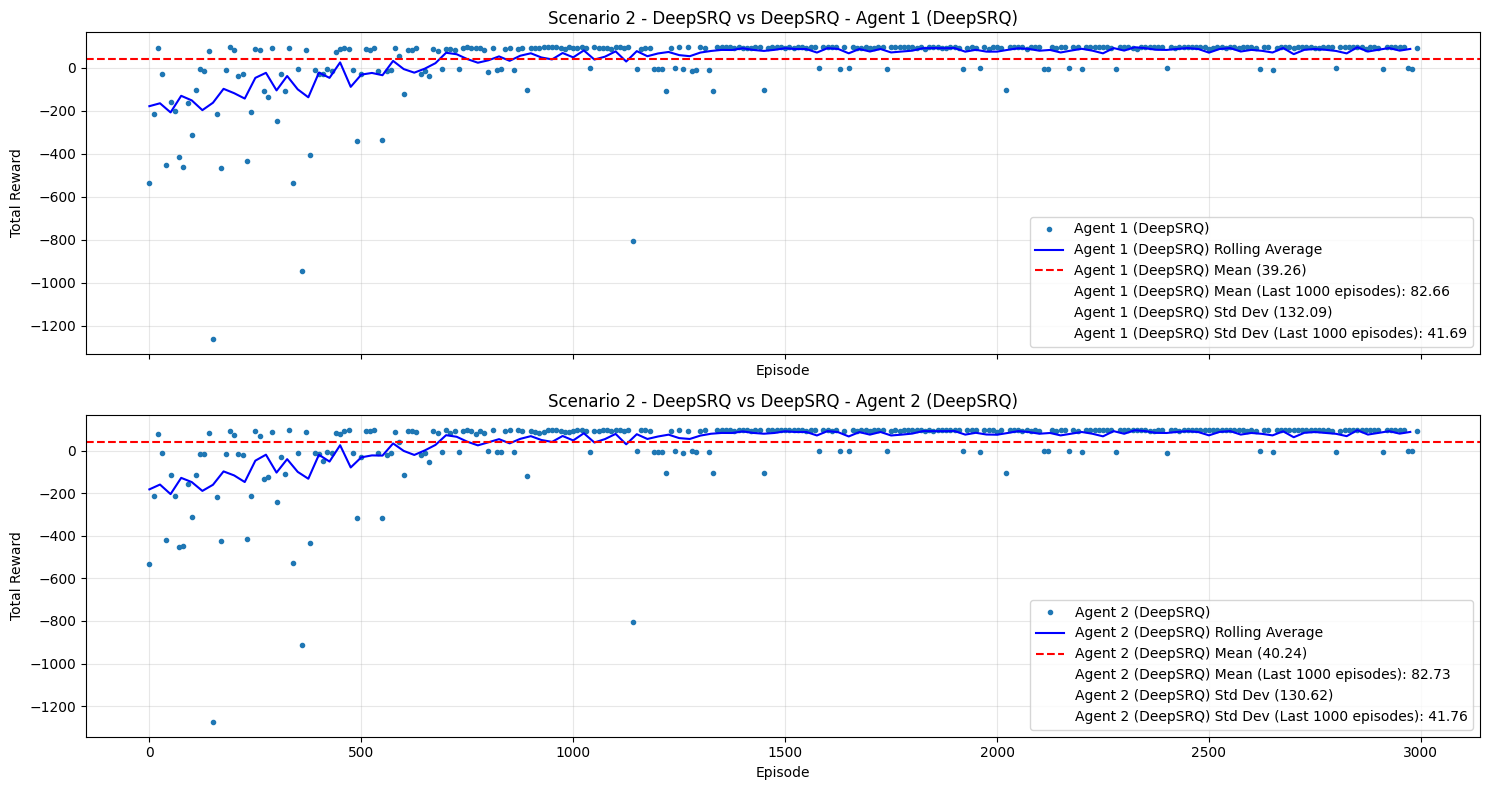

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_3026/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_3026
Wall clock: 2010.664s (33.51 min)
Episode time:   count=3000, mean=0.669540s (669540.11 us), min=0.000373s, max=5.180433s, std=0.533498s
SRE solve time: count=529155, mean=0.003223s (3222.68 us), min=0.001423s, max=0.250912s, std=0.002960s
Backend solve:  count=529155, mean=0.013969s (13969.16 us), min=0.007180s, max=0.278310s, std=0.004746s
  Agent 0 (deep_srq)
    SRE solve:  count=529155, mean=0.003223s (3222.68 us), min=0.001423s, max=0.250912s, std=0.002960s
    Backend:    count=529155, mean=0.013969s (13969.16 us), min=0.007180s, max=0.278310s, std=0.004746s
    Update:     count=36582, mean=0.039545s (39545.04 us), min=0.021462s, max=0.301734s, std=0.008741s

Reward Summary
Scenario   | Pair               | Agent         

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [37:02<00:00,  1.35it/s] 


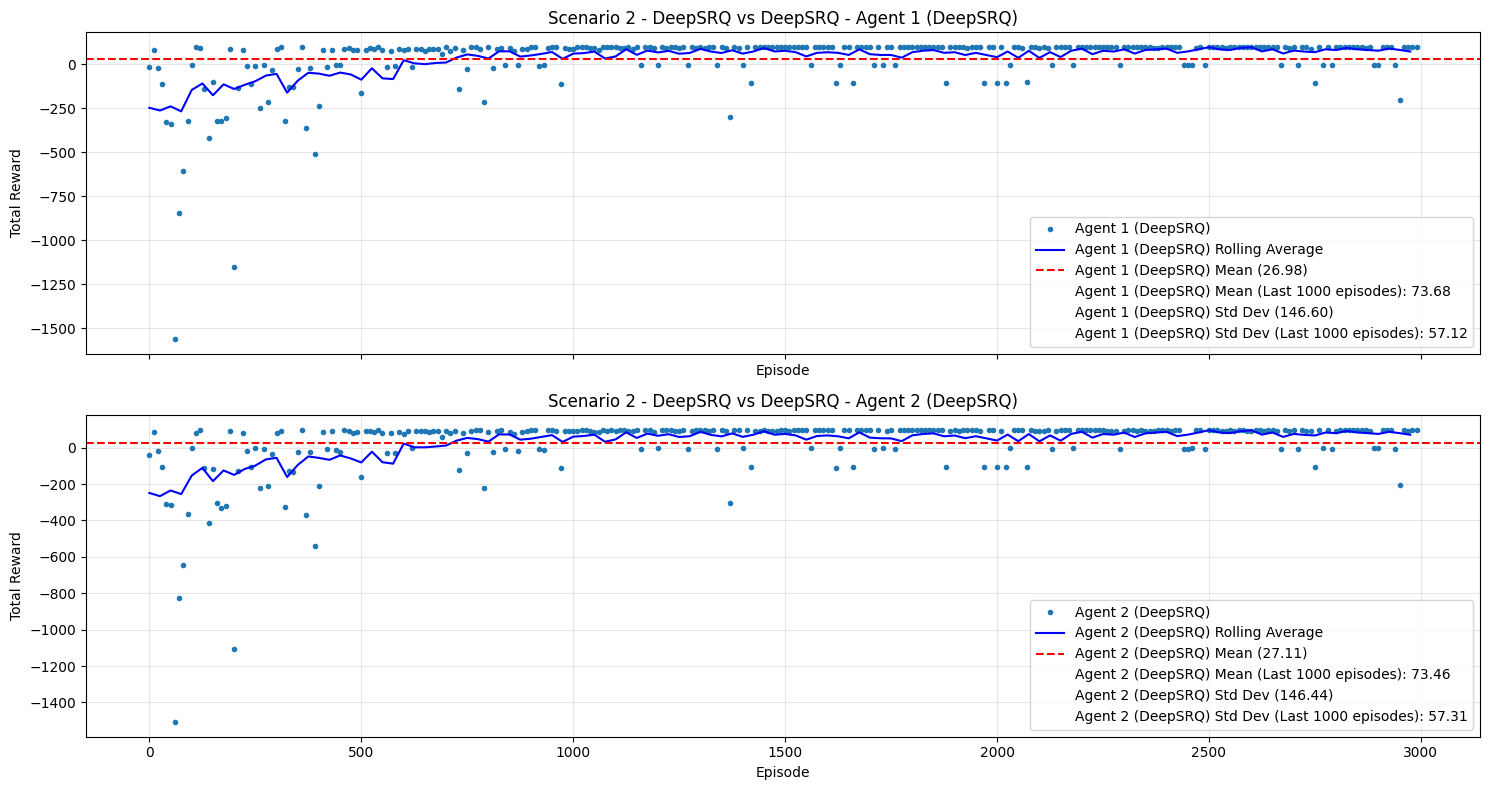

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_3027/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_3027
Wall clock: 2166.387s (36.11 min)
Episode time:   count=3000, mean=0.721457s (721457.42 us), min=0.000142s, max=4.891049s, std=0.571548s
SRE solve time: count=569395, mean=0.003235s (3235.36 us), min=0.001335s, max=0.082158s, std=0.003082s
Backend solve:  count=569395, mean=0.013838s (13837.68 us), min=0.006843s, max=0.276150s, std=0.005141s
  Agent 0 (deep_srq)
    SRE solve:  count=569395, mean=0.003235s (3235.36 us), min=0.001335s, max=0.082158s, std=0.003082s
    Backend:    count=569395, mean=0.013838s (13837.68 us), min=0.006843s, max=0.276150s, std=0.005141s
    Update:     count=38962, mean=0.040023s (40023.08 us), min=0.018619s, max=0.294654s, std=0.009123s

Reward Summary
Scenario   | Pair               | Agent             | Mean  

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:41<00:00,  1.40it/s] 


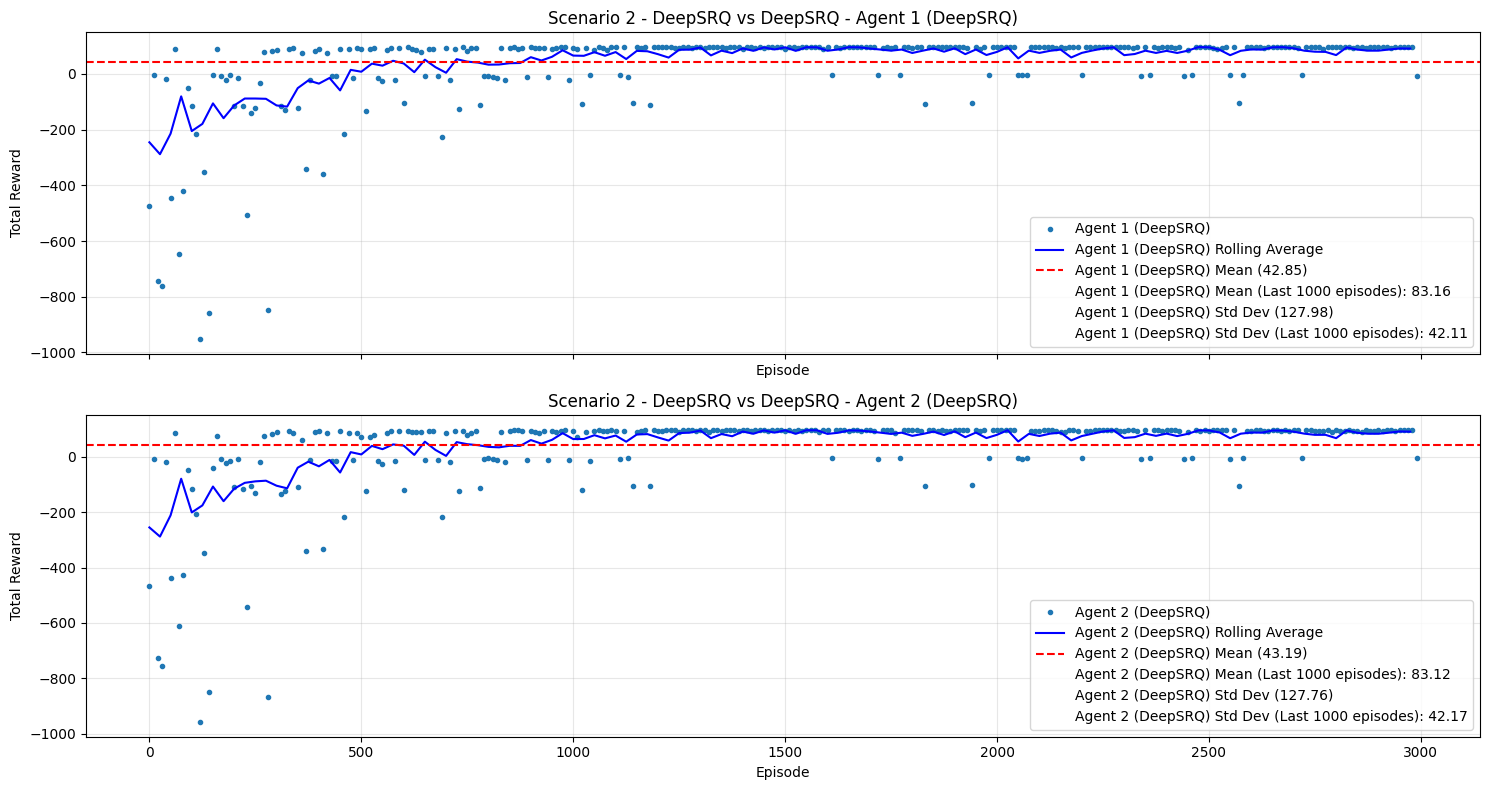

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_3125/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_3125
Wall clock: 2092.945s (34.88 min)
Episode time:   count=3000, mean=0.696967s (696967.13 us), min=0.000358s, max=6.074872s, std=0.588392s
SRE solve time: count=511532, mean=0.003509s (3509.49 us), min=0.001401s, max=0.158513s, std=0.003114s
Backend solve:  count=511532, mean=0.015088s (15087.93 us), min=0.006817s, max=0.288936s, std=0.006031s
  Agent 0 (deep_srq)
    SRE solve:  count=511532, mean=0.003509s (3509.49 us), min=0.001401s, max=0.158513s, std=0.003114s
    Backend:    count=511532, mean=0.015088s (15087.93 us), min=0.006817s, max=0.288936s, std=0.006031s
    Update:     count=35344, mean=0.043345s (43344.56 us), min=0.019464s, max=0.312416s, std=0.010430s

Reward Summary
Scenario   |

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [35:19<00:00,  1.42it/s] 


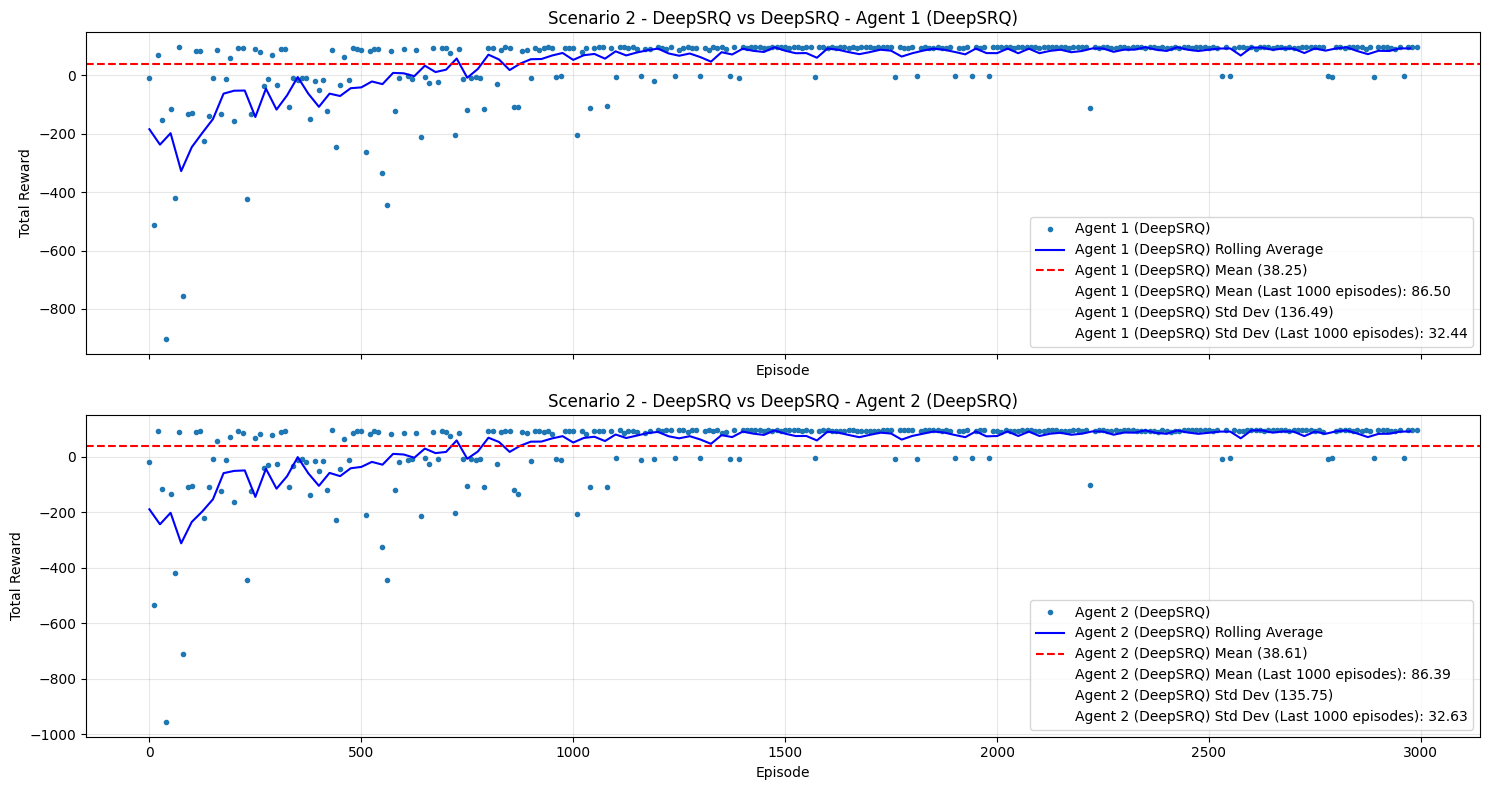

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_3126/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_3126
Wall clock: 2064.369s (34.41 min)
Episode time:   count=3000, mean=0.687445s (687445.07 us), min=0.000842s, max=4.804212s, std=0.544176s
SRE solve time: count=523930, mean=0.003357s (3357.16 us), min=0.001530s, max=0.228251s, std=0.003167s
Backend solve:  count=523930, mean=0.014329s (14328.80 us), min=0.007418s, max=0.292641s, std=0.005349s
  Agent 0 (deep_srq)
    SRE solve:  count=523930, mean=0.003357s (3357.16 us), min=0.001530s, max=0.228251s, std=0.003167s
    Backend:    count=523930, mean=0.014329s (14328.80 us), min=0.007418s, max=0.292641s, std=0.005349s
    Update:     count=36464, mean=0.040906s (40905.77 us), min=0.021021s, max=0.316967s, std=0.009609s

Reward Summary
Scenario   | Pair 

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [37:31<00:00,  1.33it/s] 


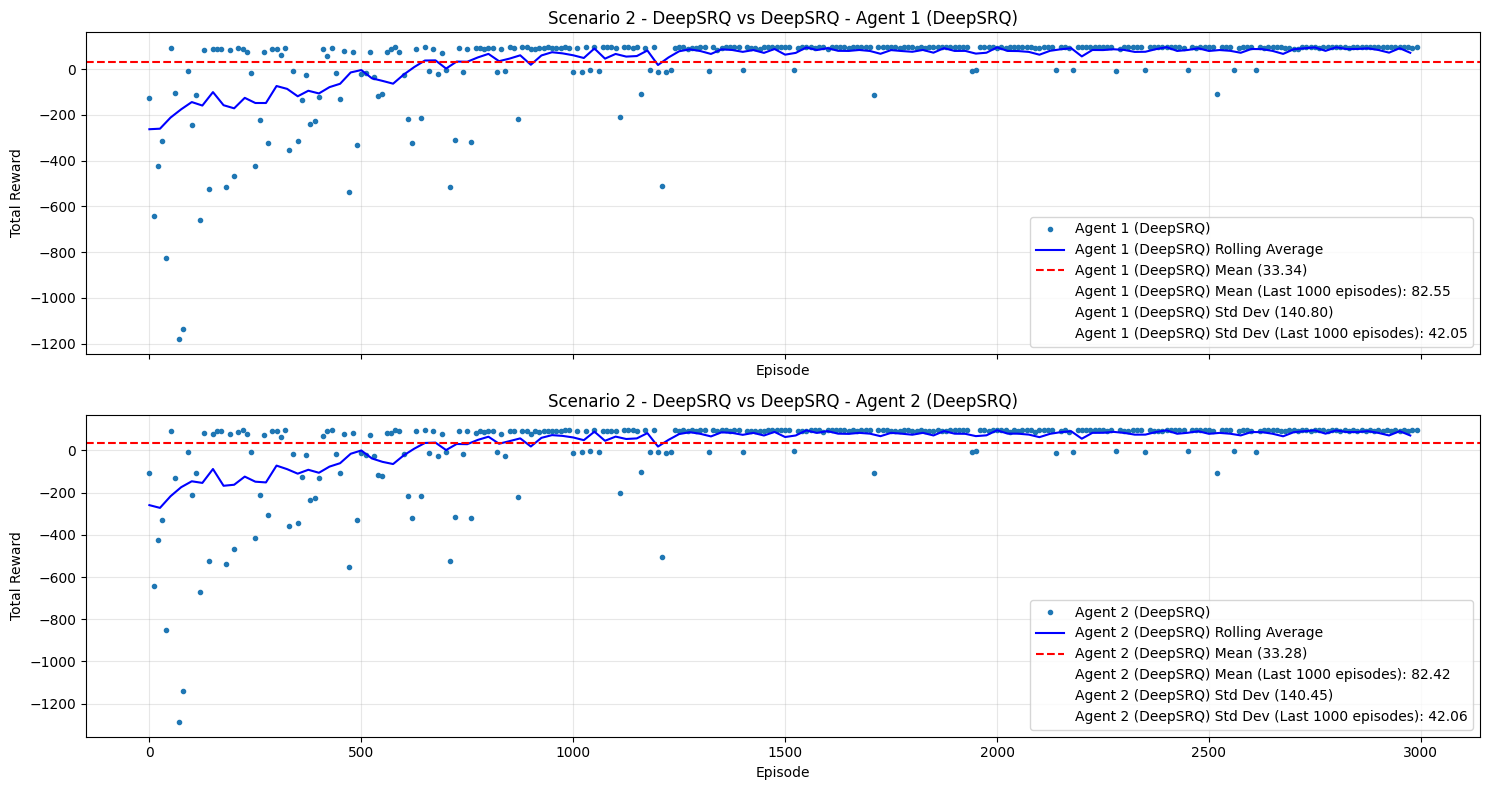

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_eps1_exponential_3127/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_eps1_exponential_3127
Wall clock: 2184.541s (36.41 min)
Episode time:   count=3000, mean=0.727492s (727492.14 us), min=0.000268s, max=5.322182s, std=0.612237s
SRE solve time: count=546761, mean=0.003389s (3389.00 us), min=0.001300s, max=0.262286s, std=0.003169s
Backend solve:  count=546761, mean=0.014353s (14352.61 us), min=0.006895s, max=0.280425s, std=0.005749s
  Agent 0 (deep_srq)
    SRE solve:  count=546761, mean=0.003389s (3389.00 us), min=0.001300s, max=0.262286s, std=0.003169s
    Backend:    count=546761, mean=0.014353s (14352.61 us), min=0.006895s, max=0.280425s, std=0.005749s
    Update:     count=37624, mean=0.042236s (42236.19 us), min=0.020081s, max=0.287465s, std=0.010240s

Reward Summary
Scenario   | Pair             

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [34:45<00:00,  1.44it/s] 


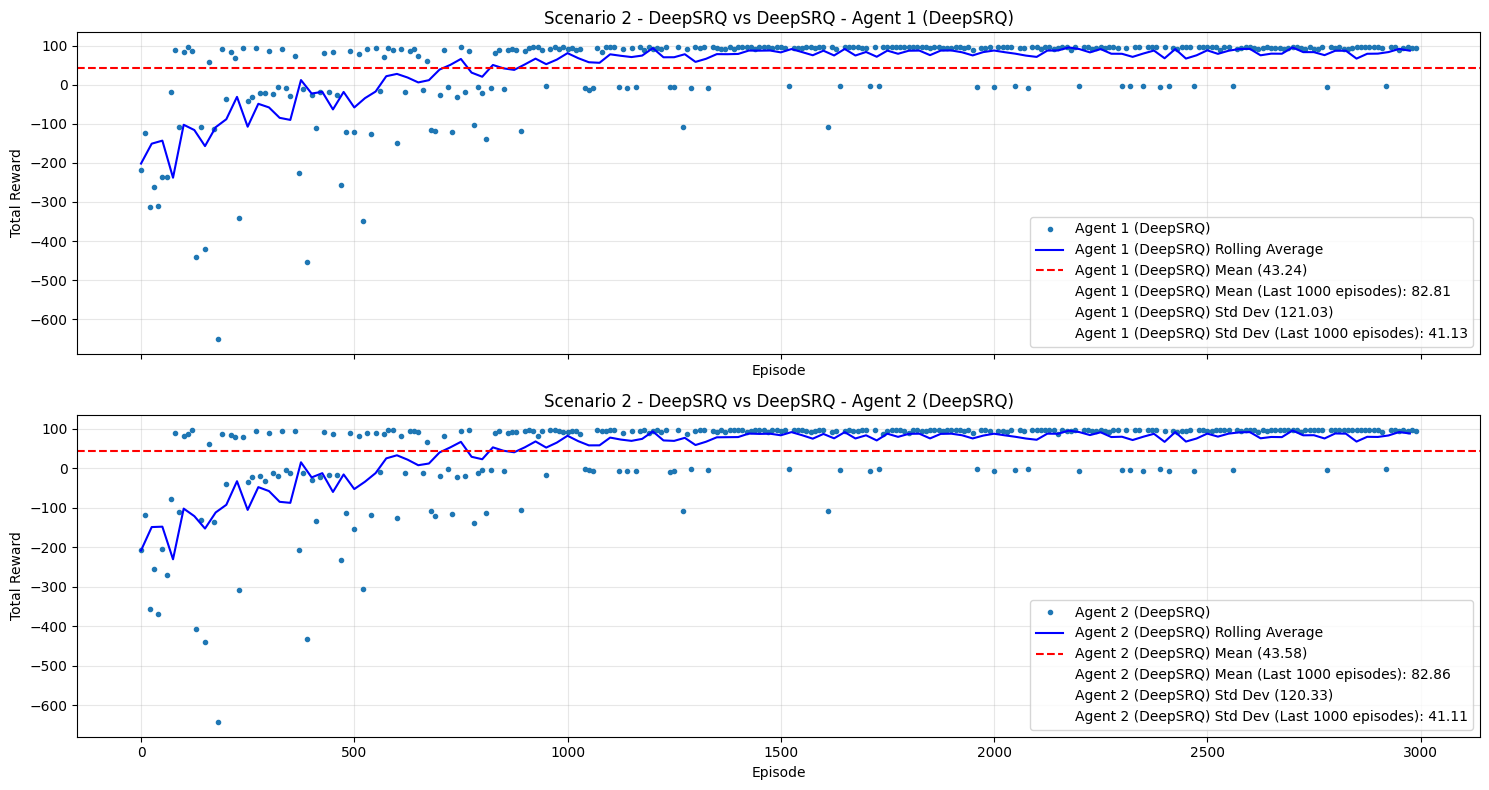

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_constant_eps0.25_vs_deep_srq_constant_eps0.25_eps0.25_constant_3225/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps0.25_vs_deep_srq_constant_eps0.25_eps0.25_constant_3225
Wall clock: 2018.529s (33.64 min)
Episode time:   count=3000, mean=0.672113s (672113.11 us), min=0.000368s, max=5.531352s, std=0.556398s
SRE solve time: count=518682, mean=0.003222s (3221.79 us), min=0.001309s, max=0.078973s, std=0.002961s
Backend solve:  count=518682, mean=0.013734s (13734.29 us), min=0.006776s, max=0.351957s, std=0.005178s
  Agent 0 (deep_srq)
    SRE solve:  count=518682, mean=0.003222s (3221.79 us), min=0.001309s, max=0.078973s, std=0.002961s
    Backend:    count=518682, mean=0.013734s (13734.29 us), min=0.006776s, max=0.351957s, std=0.005178s
    Update:     count=36019, mean=0.040673s (40673.21 us), min=0.021071s, max=0.361153s, std=0.010160s

Reward Summary
Scenario   | Pair             

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [57:50<00:00,  1.16s/it]  


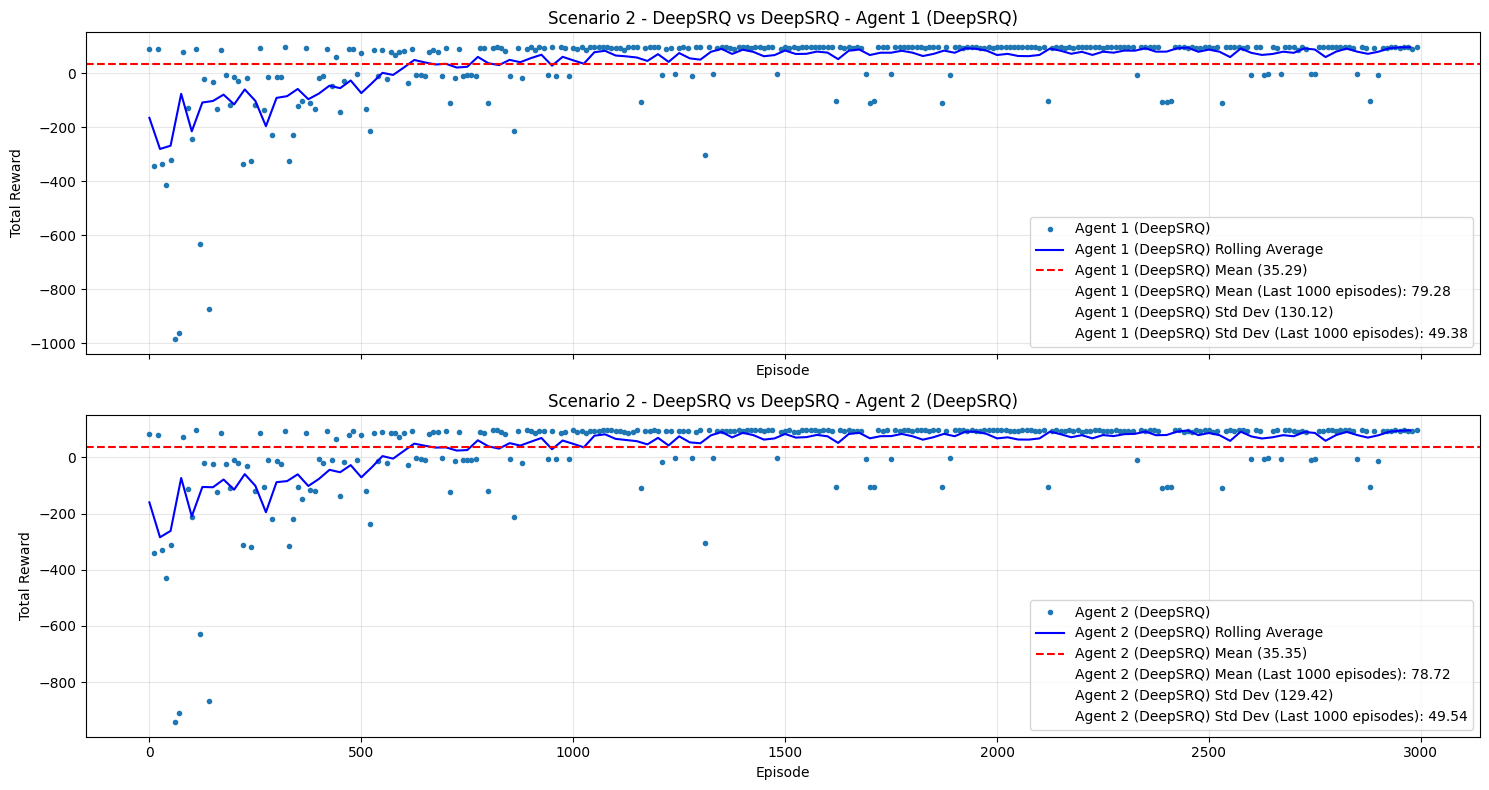

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_constant_eps0.5_vs_deep_srq_constant_eps0.5_eps0.5_constant_3226/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps0.5_vs_deep_srq_constant_eps0.5_eps0.5_constant_3226
Wall clock: 3363.784s (56.06 min)
Episode time:   count=3000, mean=1.119509s (1119508.70 us), min=0.000418s, max=5.952015s, std=0.773347s
SRE solve time: count=545937, mean=0.005225s (5224.55 us), min=0.001492s, max=0.303318s, std=0.008721s
Backend solve:  count=545937, mean=0.019155s (19155.17 us), min=0.007070s, max=0.506592s, std=0.014612s
  Agent 0 (deep_srq)
    SRE solve:  count=545937, mean=0.005225s (5224.55 us), min=0.001492s, max=0.303318s, std=0.008721s
    Backend:    count=545937, mean=0.019155s (19155.17 us), min=0.007070s, max=0.506592s, std=0.014612s
    Update:     count=37501, mean=0.059400s (59400.37 us), min=0.022412s, max=0.626115s, std=0.040060s

Reward Summary
Scenario   | Pair               | A

scenario2: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [37:47<00:00,  1.32it/s] 


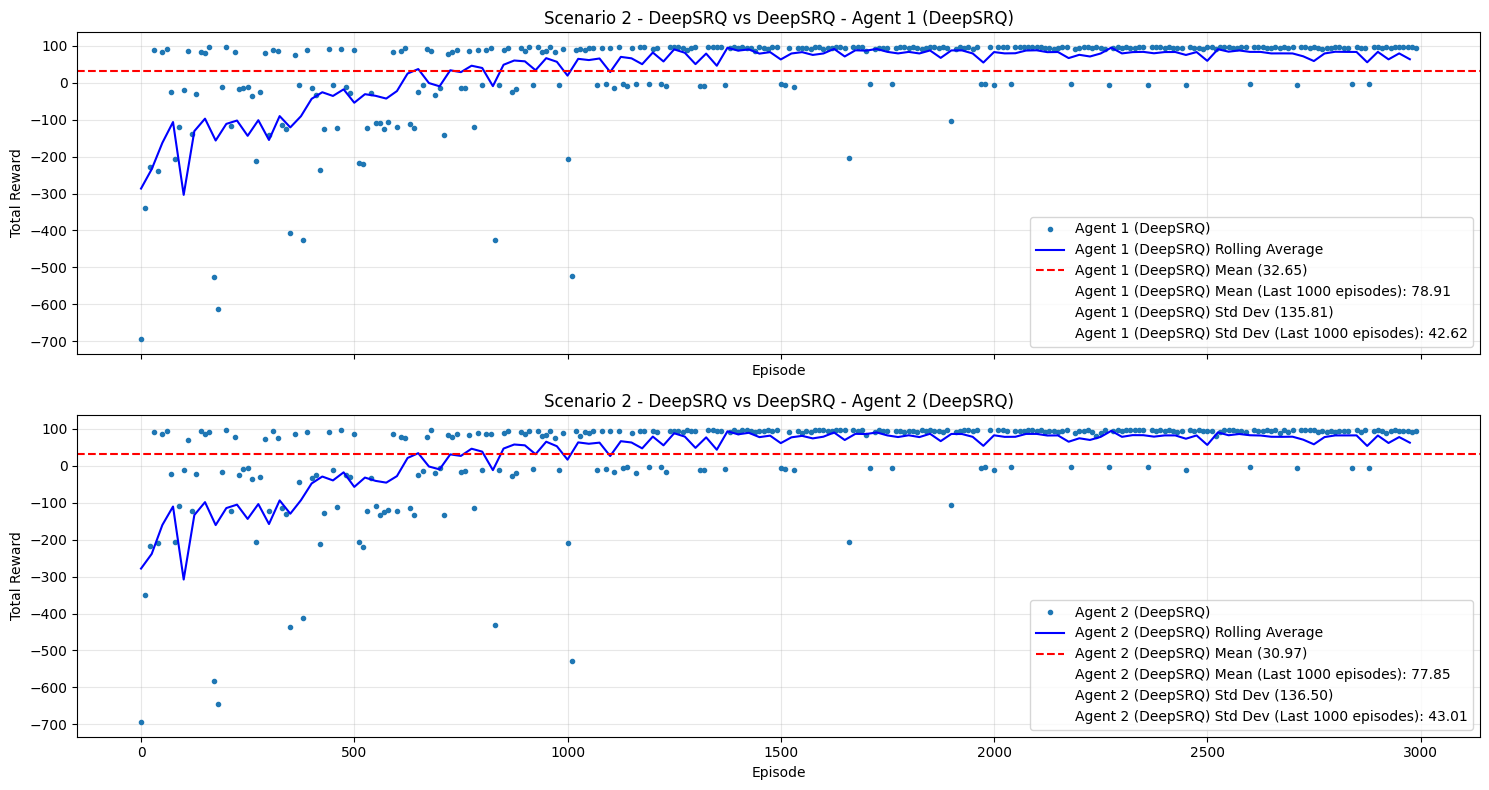

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario2/deep_srq_constant_eps1_vs_deep_srq_constant_eps1_eps1_constant_3227/training_stats.txt
Scenario 2 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps1_vs_deep_srq_constant_eps1_eps1_constant_3227
Wall clock: 2192.764s (36.55 min)
Episode time:   count=3000, mean=0.730223s (730222.73 us), min=0.000191s, max=4.948178s, std=0.539744s
SRE solve time: count=575894, mean=0.003149s (3148.76 us), min=0.001339s, max=0.175558s, std=0.003032s
Backend solve:  count=575894, mean=0.013258s (13257.82 us), min=0.006886s, max=1.632527s, std=0.005845s
  Agent 0 (deep_srq)
    SRE solve:  count=575894, mean=0.003149s (3148.76 us), min=0.001339s, max=0.175558s, std=0.003032s
    Backend:    count=575894, mean=0.013258s (13257.82 us), min=0.006886s, max=1.632527s, std=0.005845s
    Update:     count=39780, mean=0.039757s (39756.92 us), min=0.018221s, max=1.652425s, std=0.014275s

Reward Summary
Scenario   | Pair               | Agent         

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [53:36<00:00,  1.07s/it] 


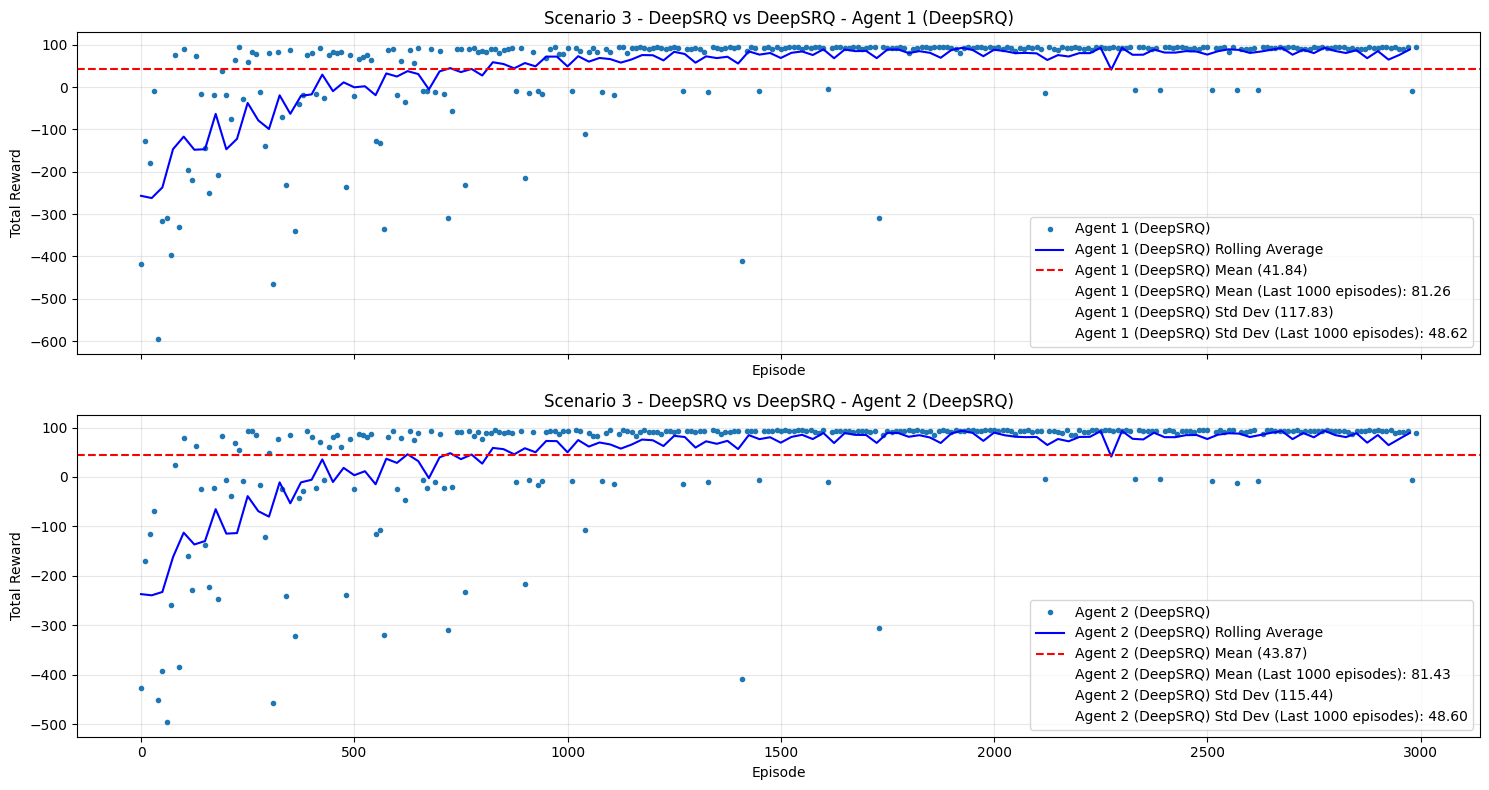

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_4025/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_4025
Wall clock: 3101.760s (51.70 min)
Episode time:   count=3000, mean=1.033170s (1033169.67 us), min=0.000945s, max=5.195558s, std=0.804072s
SRE solve time: count=846616, mean=0.003028s (3028.24 us), min=0.001274s, max=0.157415s, std=0.002789s
Backend solve:  count=846616, mean=0.013539s (13539.10 us), min=0.006763s, max=0.406605s, std=0.004945s
  Agent 0 (deep_srq)
    SRE solve:  count=846616, mean=0.003028s (3028.24 us), min=0.001274s, max=0.157415s, std=0.002789s
    Backend:    count=846616, mean=0.013539s (13539.10 us), min=0.006763s, max=0.406605s, std=0.004945s
    Update:     count=54700, mean=0.041872s (41871.70 us), min=0.024567s, max=0.614717s, std=0.009217s

Reward Summary
Scenario   | Pair               | Agent  

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [52:05<00:00,  1.04s/it] 


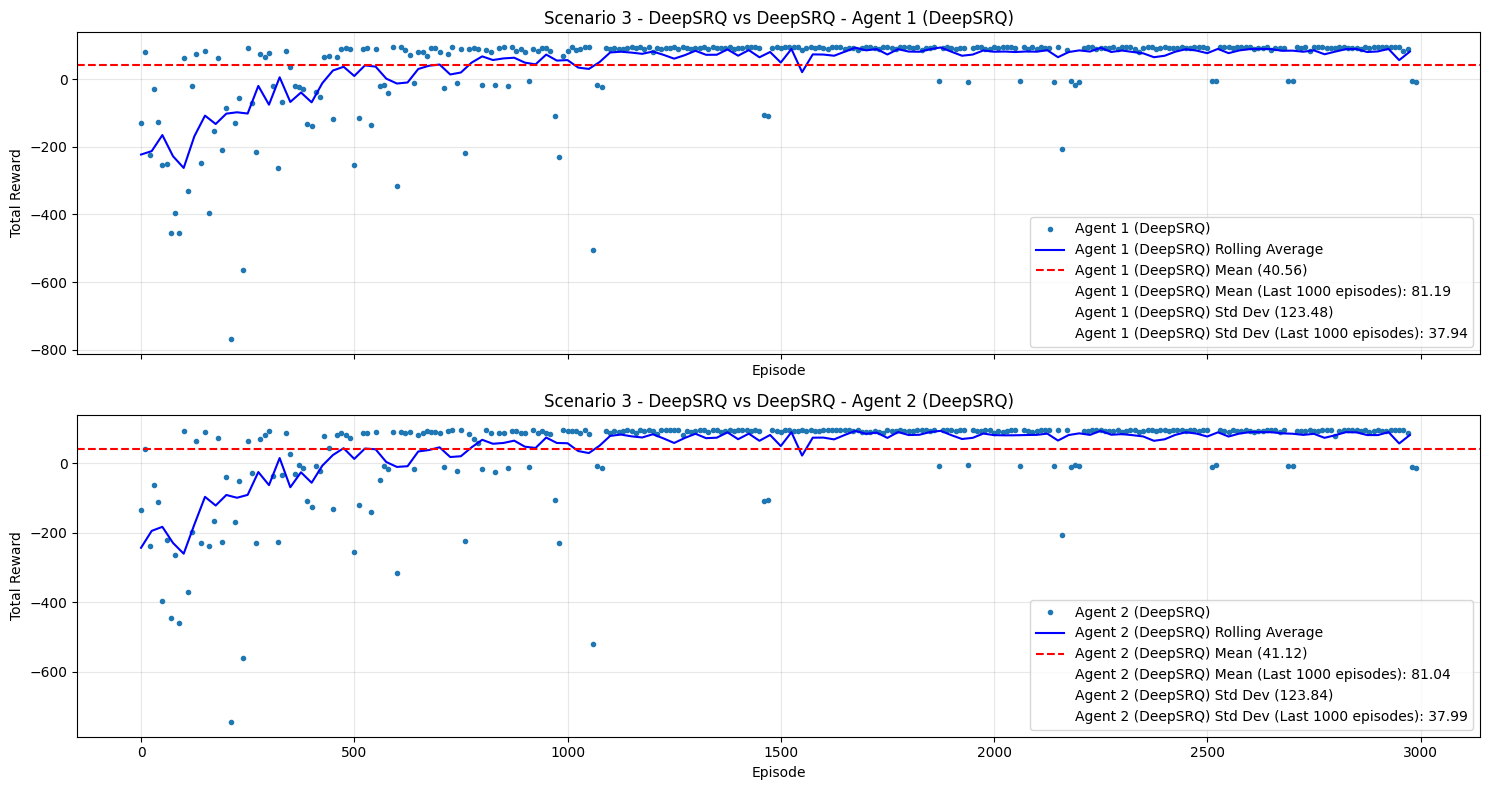

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_4026/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_4026
Wall clock: 3003.762s (50.06 min)
Episode time:   count=3000, mean=1.000521s (1000520.97 us), min=0.001752s, max=6.492806s, std=0.820034s
SRE solve time: count=845054, mean=0.002928s (2928.23 us), min=0.001332s, max=0.158129s, std=0.002659s
Backend solve:  count=845054, mean=0.013195s (13195.26 us), min=0.006747s, max=0.828329s, std=0.004705s
  Agent 0 (deep_srq)
    SRE solve:  count=845054, mean=0.002928s (2928.23 us), min=0.001332s, max=0.158129s, std=0.002659s
    Backend:    count=845054, mean=0.013195s (13195.26 us), min=0.006747s, max=0.828329s, std=0.004705s
    Update:     count=54646, mean=0.040741s (40740.69 us), min=0.022875s, max=0.837258s, std=0.009472s

Reward Summary
Scenario   | Pair               | Agent        

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [50:55<00:00,  1.02s/it] 


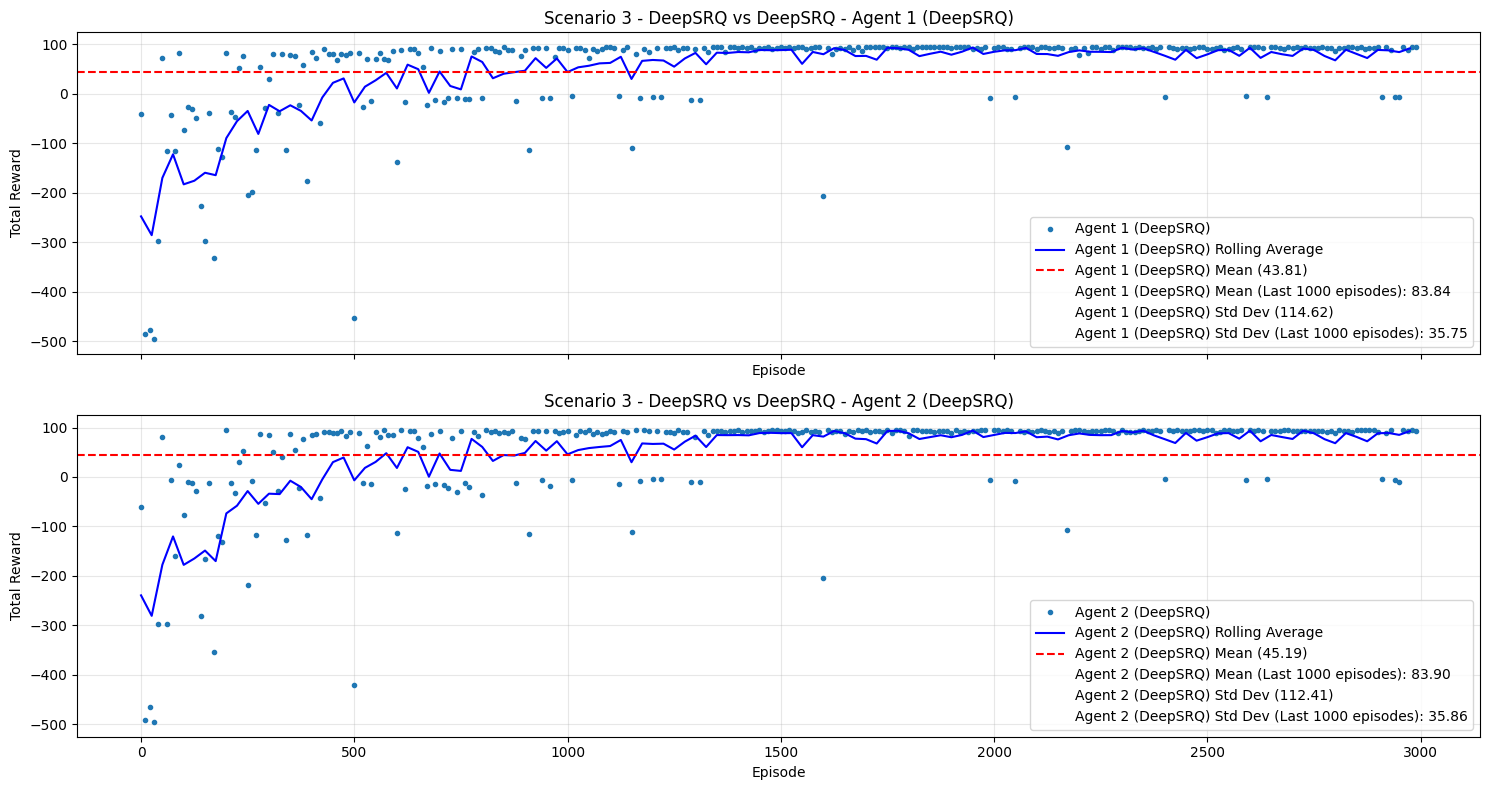

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_4027/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_4027
Wall clock: 2932.646s (48.88 min)
Episode time:   count=3000, mean=0.976807s (976807.09 us), min=0.002033s, max=6.799984s, std=0.756665s
SRE solve time: count=847767, mean=0.002834s (2834.09 us), min=0.001152s, max=0.065261s, std=0.002643s
Backend solve:  count=847767, mean=0.012730s (12729.70 us), min=0.006384s, max=0.901180s, std=0.004643s
  Agent 0 (deep_srq)
    SRE solve:  count=847767, mean=0.002834s (2834.09 us), min=0.001152s, max=0.065261s, std=0.002643s
    Backend:    count=847767, mean=0.012730s (12729.70 us), min=0.006384s, max=0.901180s, std=0.004643s
    Update:     count=54826, mean=0.039393s (39392.94 us), min=0.021899s, max=0.919415s, std=0.009640s

Reward Summary
Scenario   | Pair               | Agent             | Mean  

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [52:20<00:00,  1.05s/it]  


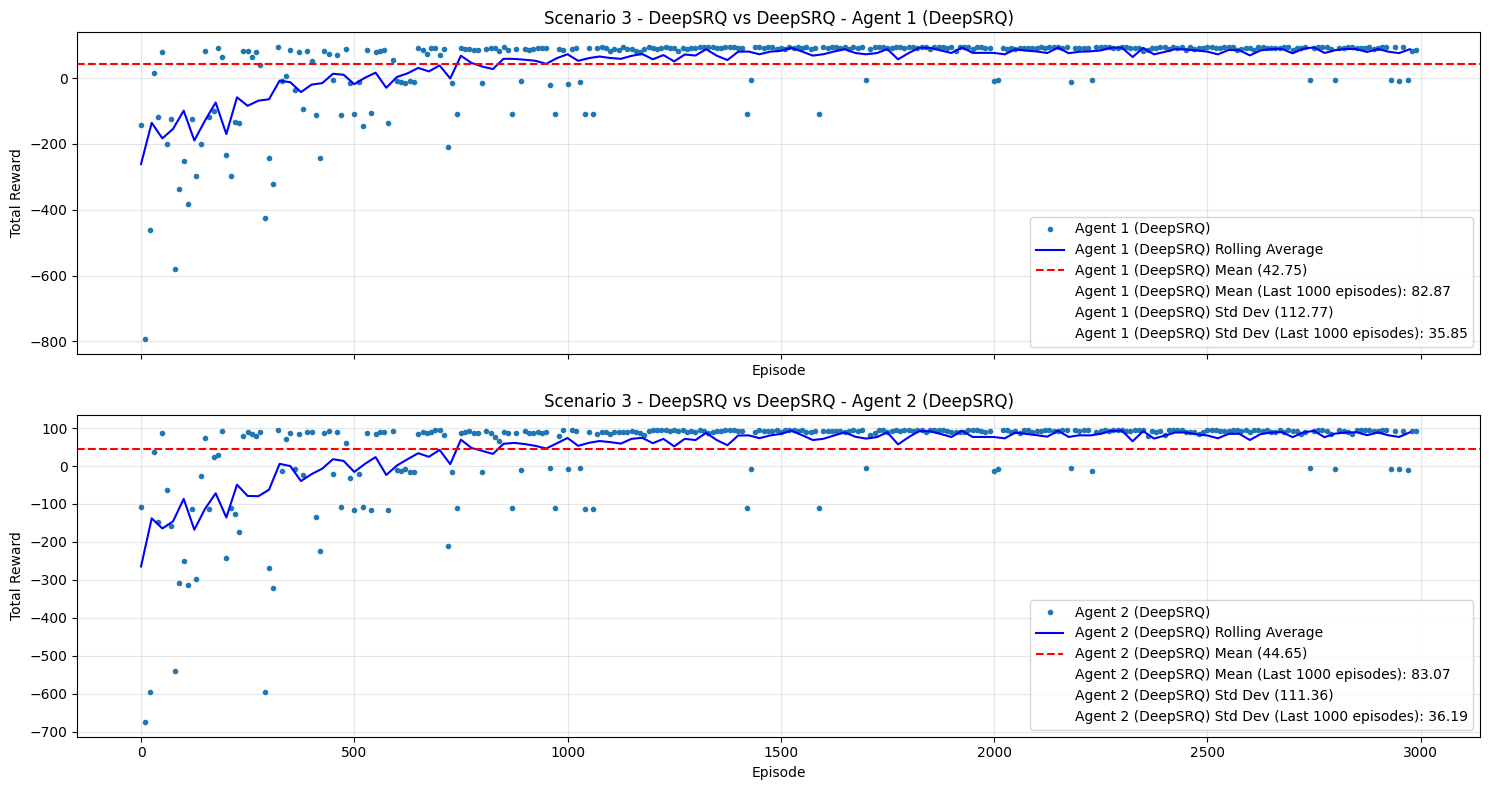

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_4125/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_4125
Wall clock: 3008.681s (50.14 min)
Episode time:   count=3000, mean=1.002142s (1002141.99 us), min=0.001867s, max=5.164572s, std=0.746173s
SRE solve time: count=827553, mean=0.003008s (3007.91 us), min=0.001218s, max=0.176242s, std=0.002833s
Backend solve:  count=827553, mean=0.013411s (13410.61 us), min=0.006715s, max=0.775403s, std=0.004821s
  Agent 0 (deep_srq)
    SRE solve:  count=827553, mean=0.003008s (3007.91 us), min=0.001218s, max=0.176242s, std=0.002833s
    Backend:    count=827553, mean=0.013411s (13410.61 us), min=0.006715s, max=0.775403s, std=0.004821s
    Update:     count=53577, mean=0.041132s (41131.97 us), min=0.019079s, max=0.797843s, std=0.009541s

Reward Summary
Scenario   

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [52:06<00:00,  1.04s/it] 


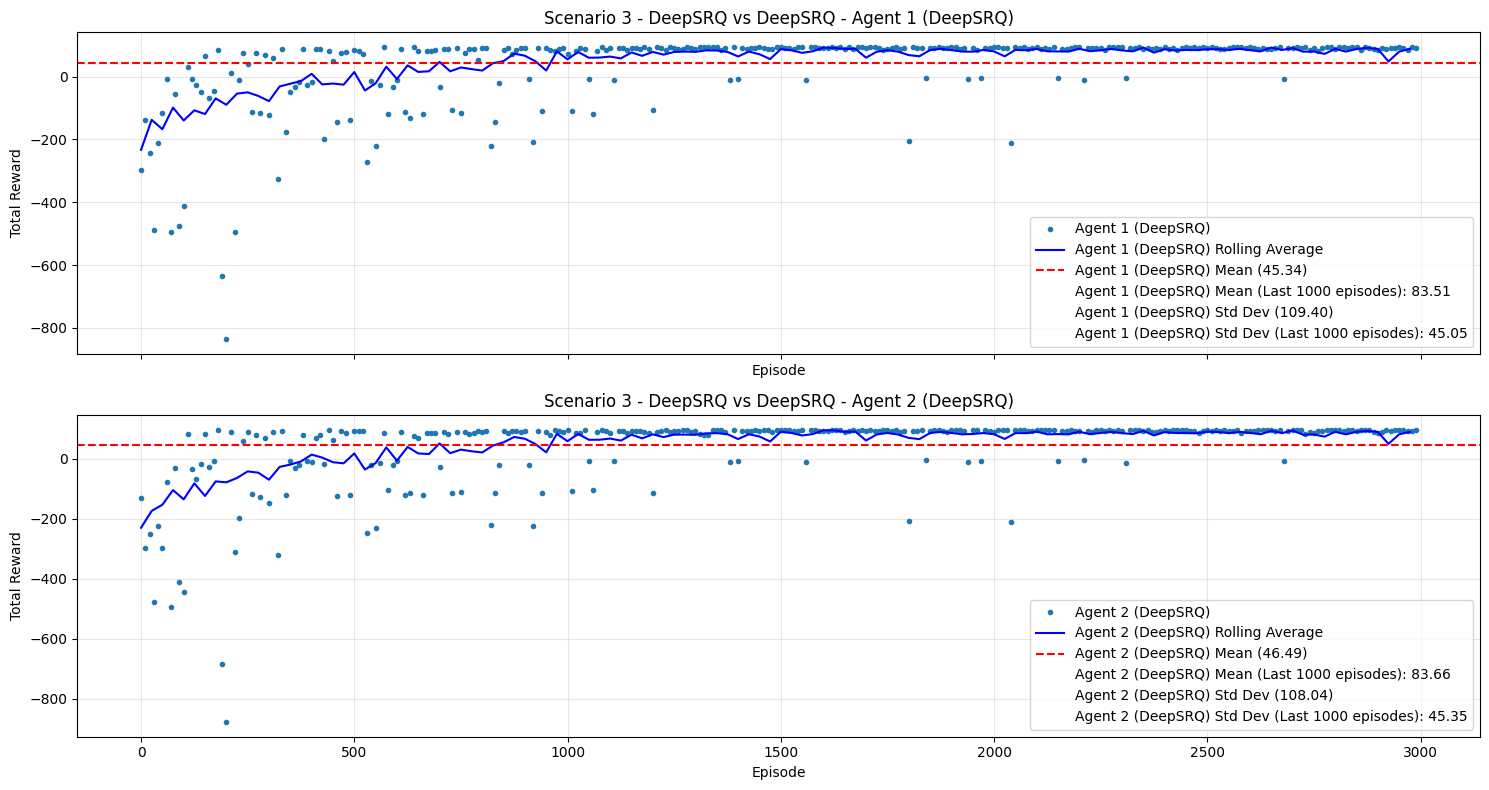

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_4126/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_4126
Wall clock: 2987.850s (49.80 min)
Episode time:   count=3000, mean=0.995211s (995210.73 us), min=0.000585s, max=5.438649s, std=0.763851s
SRE solve time: count=828969, mean=0.002968s (2967.63 us), min=0.001227s, max=0.072615s, std=0.002757s
Backend solve:  count=828969, mean=0.013182s (13182.39 us), min=0.006679s, max=0.766850s, std=0.004714s
  Agent 0 (deep_srq)
    SRE solve:  count=828969, mean=0.002968s (2967.63 us), min=0.001227s, max=0.072615s, std=0.002757s
    Backend:    count=828969, mean=0.013182s (13182.39 us), min=0.006679s, max=0.766850s, std=0.004714s
    Update:     count=54185, mean=0.040448s (40447.73 us), min=0.020763s, max=0.775337s, std=0.009185s

Reward Summary
Scenario   | Pair 

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [54:09<00:00,  1.08s/it] 


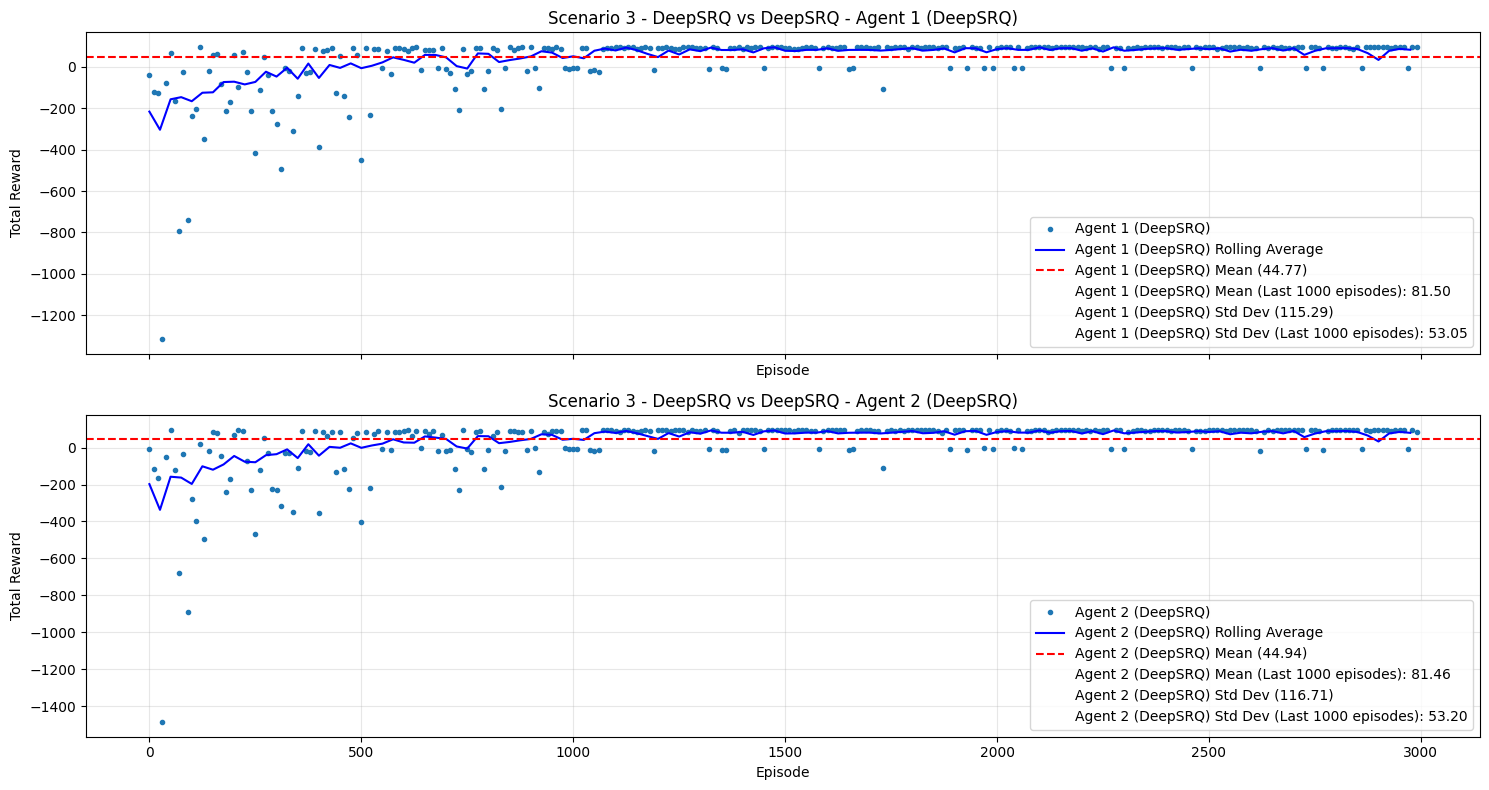

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_eps1_exponential_4127/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_eps1_exponential_4127
Wall clock: 3095.312s (51.59 min)
Episode time:   count=3000, mean=1.031016s (1031016.26 us), min=0.002188s, max=7.709371s, std=0.805705s
SRE solve time: count=855817, mean=0.002985s (2985.28 us), min=0.001165s, max=0.258184s, std=0.002789s
Backend solve:  count=855817, mean=0.013304s (13304.20 us), min=0.006427s, max=0.750399s, std=0.005072s
  Agent 0 (deep_srq)
    SRE solve:  count=855817, mean=0.002985s (2985.28 us), min=0.001165s, max=0.258184s, std=0.002789s
    Backend:    count=855817, mean=0.013304s (13304.20 us), min=0.006427s, max=0.750399s, std=0.005072s
    Update:     count=55210, mean=0.041397s (41396.84 us), min=0.023611s, max=0.757713s, std=0.009483s

Reward Summary
Scenario   | Pair            

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [51:33<00:00,  1.03s/it] 


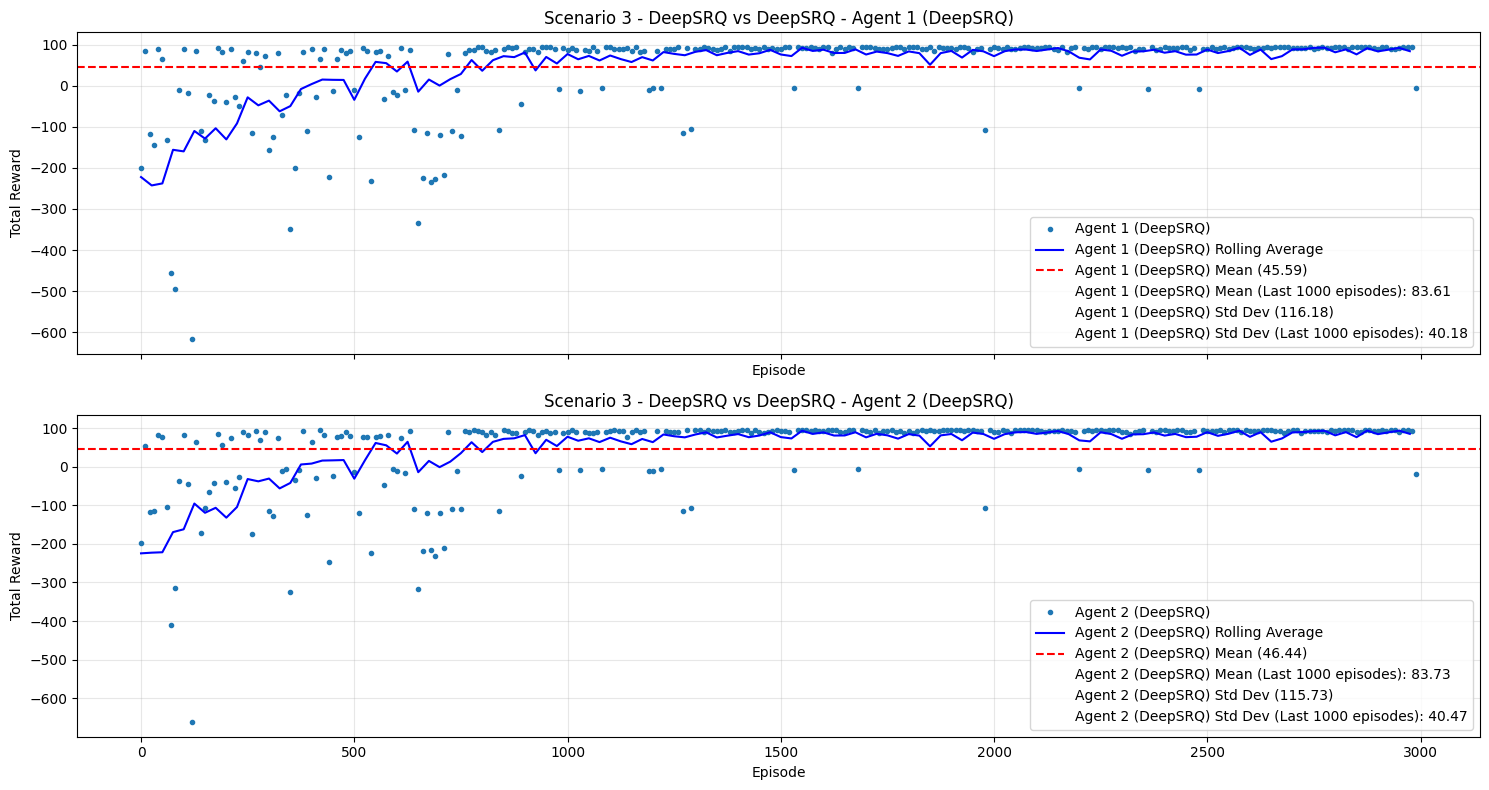

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_constant_eps0.25_vs_deep_srq_constant_eps0.25_eps0.25_constant_4225/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps0.25_vs_deep_srq_constant_eps0.25_eps0.25_constant_4225
Wall clock: 2942.480s (49.04 min)
Episode time:   count=3000, mean=0.980087s (980087.26 us), min=0.000816s, max=5.324078s, std=0.780965s
SRE solve time: count=818664, mean=0.002976s (2976.31 us), min=0.001225s, max=0.154096s, std=0.002699s
Backend solve:  count=818664, mean=0.013264s (13264.34 us), min=0.006582s, max=0.362705s, std=0.004931s
  Agent 0 (deep_srq)
    SRE solve:  count=818664, mean=0.002976s (2976.31 us), min=0.001225s, max=0.154096s, std=0.002699s
    Backend:    count=818664, mean=0.013264s (13264.34 us), min=0.006582s, max=0.362705s, std=0.004931s
    Update:     count=52888, mean=0.041159s (41158.88 us), min=0.024441s, max=0.370767s, std=0.009247s

Reward Summary
Scenario   | Pair             

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [51:29<00:00,  1.03s/it] 


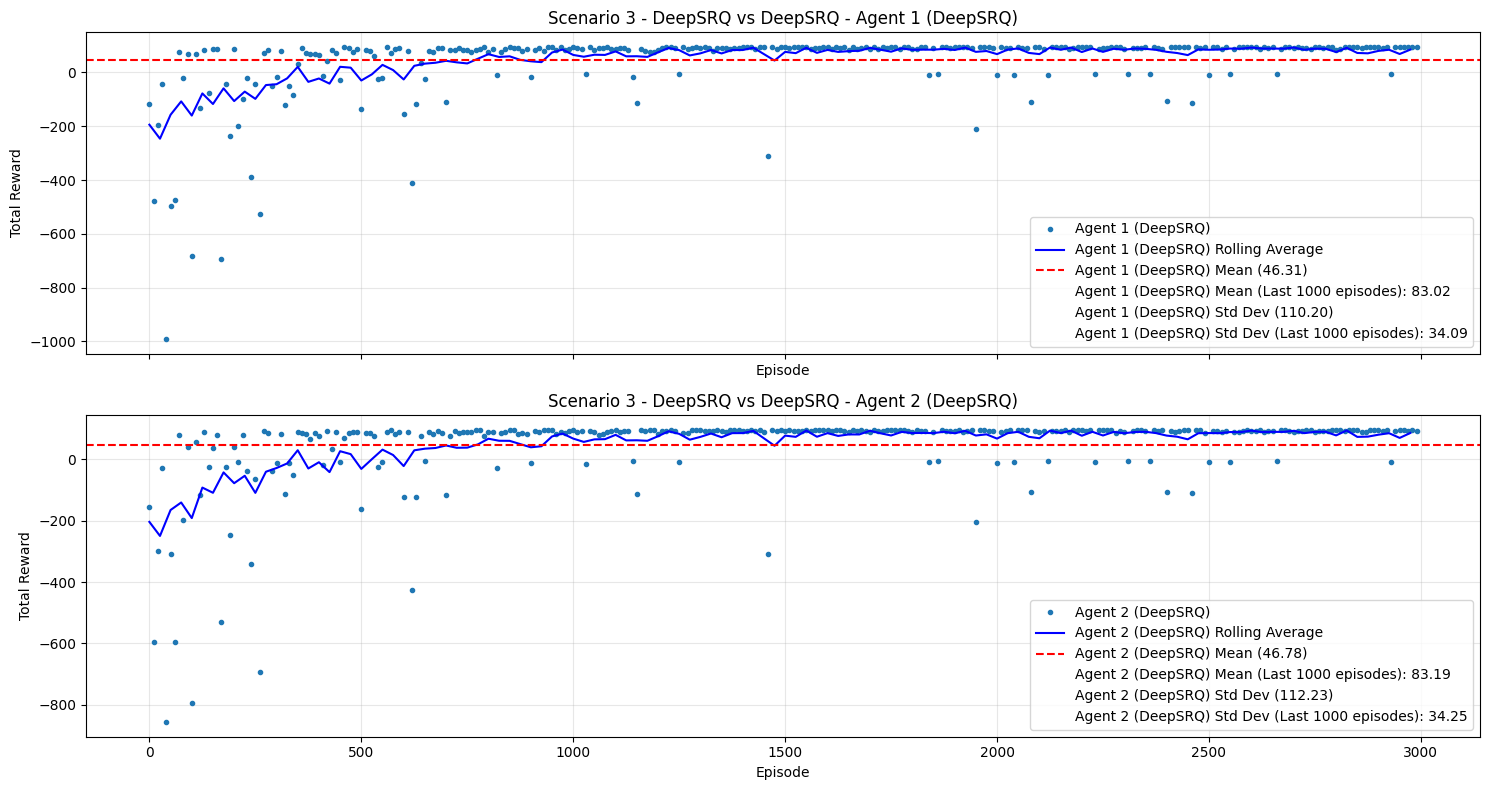

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_constant_eps0.5_vs_deep_srq_constant_eps0.5_eps0.5_constant_4226/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps0.5_vs_deep_srq_constant_eps0.5_eps0.5_constant_4226
Wall clock: 2933.743s (48.90 min)
Episode time:   count=3000, mean=0.977185s (977184.65 us), min=0.000732s, max=5.279191s, std=0.777723s
SRE solve time: count=837131, mean=0.002876s (2875.94 us), min=0.001192s, max=0.235942s, std=0.002610s
Backend solve:  count=837131, mean=0.012837s (12837.28 us), min=0.006363s, max=0.346583s, std=0.004517s
  Agent 0 (deep_srq)
    SRE solve:  count=837131, mean=0.002876s (2875.94 us), min=0.001192s, max=0.235942s, std=0.002610s
    Backend:    count=837131, mean=0.012837s (12837.28 us), min=0.006363s, max=0.346583s, std=0.004517s
    Update:     count=54495, mean=0.039710s (39709.99 us), min=0.021176s, max=0.355024s, std=0.008341s

Reward Summary
Scenario   | Pair               | Ag

scenario3: deep_srq_vs_deep_srq: 100%|██████████| 3000/3000 [51:37<00:00,  1.03s/it] 


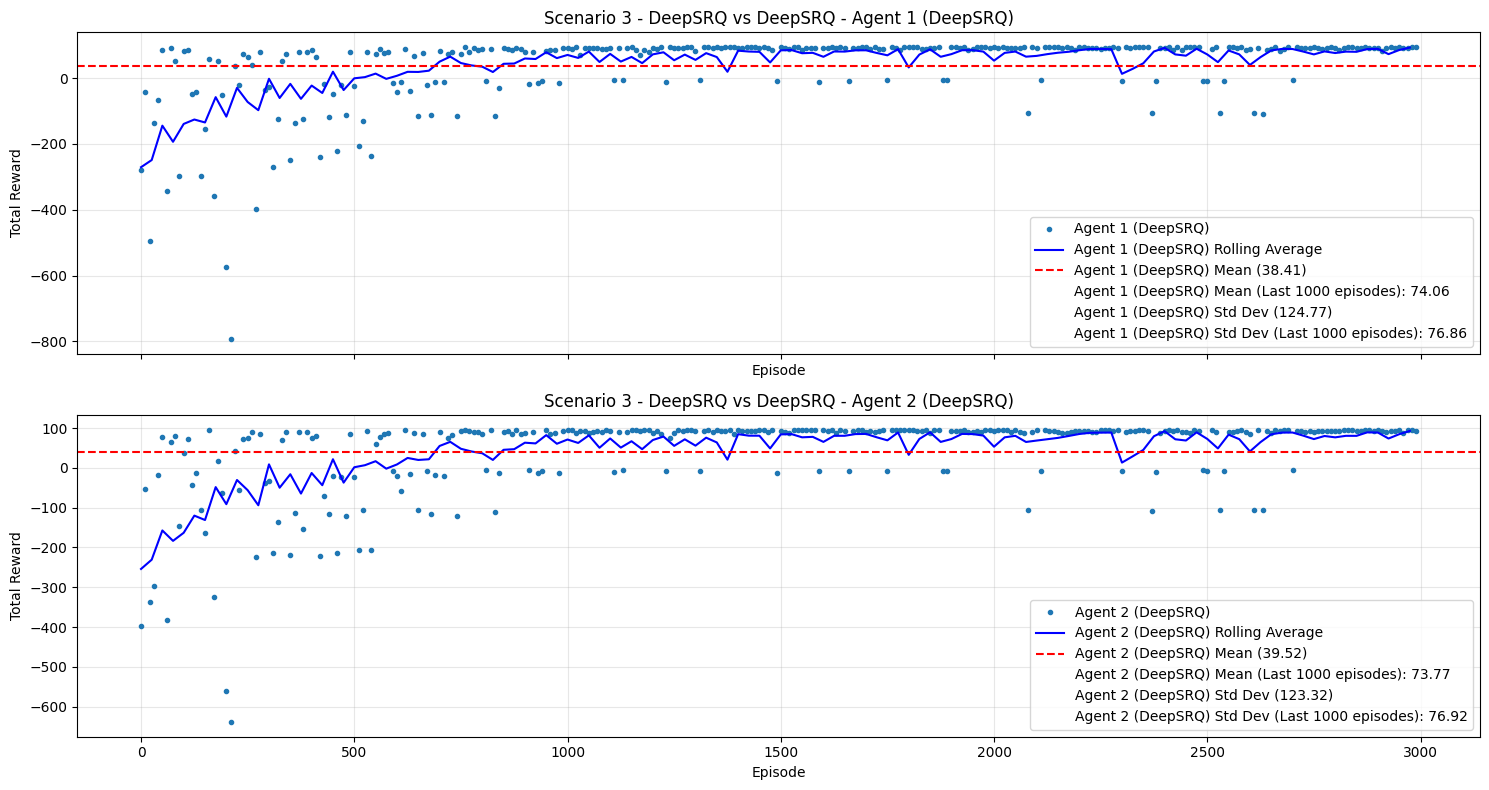

Saved stats to full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario3/deep_srq_constant_eps1_vs_deep_srq_constant_eps1_eps1_constant_4227/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - deep_srq_constant_eps1_vs_deep_srq_constant_eps1_eps1_constant_4227
Wall clock: 2938.129s (48.97 min)
Episode time:   count=3000, mean=0.978656s (978656.36 us), min=0.000717s, max=6.008631s, std=0.763465s
SRE solve time: count=859229, mean=0.002799s (2798.94 us), min=0.001194s, max=0.279067s, std=0.002623s
Backend solve:  count=859229, mean=0.012549s (12549.04 us), min=0.006296s, max=0.327957s, std=0.004664s
  Agent 0 (deep_srq)
    SRE solve:  count=859229, mean=0.002799s (2798.94 us), min=0.001194s, max=0.279067s, std=0.002623s
    Backend:    count=859229, mean=0.012549s (12549.04 us), min=0.006296s, max=0.327957s, std=0.004664s
    Update:     count=55553, mean=0.039084s (39083.77 us), min=0.020110s, max=0.346560s, std=0.009220s

Reward Summary
Scenario   | Pair               | Agent         

PosixPath('full_pair_comparison_runs/deep_srq_vs_deep_srq_manifest.txt')

In [4]:
deep_srq_vs_deep_srq_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "deep_srq"),
    case_slug="deep_srq_vs_deep_srq",
    case_seed_offset=0,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_deep_srq_manifest.txt",
    deep_srq_vs_deep_srq_results,
)


## Deep SRQ vs Tabular SRQ

Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_linear_eps0.25_vs_srq_linear_eps0.25_eps0.25_linear_12025/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_linear_eps0.5_vs_srq_linear_eps0.5_eps0.5_linear_12026/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_linear_eps1_vs_srq_linear_eps1_eps1_linear_12027/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_exponential_eps0.25_vs_srq_exponential_eps0.25_eps0.25_exponential_12125/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_exponential_eps0.5_vs_srq_exponential_eps0.5_eps0.5_exponential_12126/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_exponential_eps1_vs_srq_exponential_eps1_eps1_ex

scenario2: deep_srq_vs_srq: 100%|██████████| 3000/3000 [58:05<00:00,  1.16s/it]  


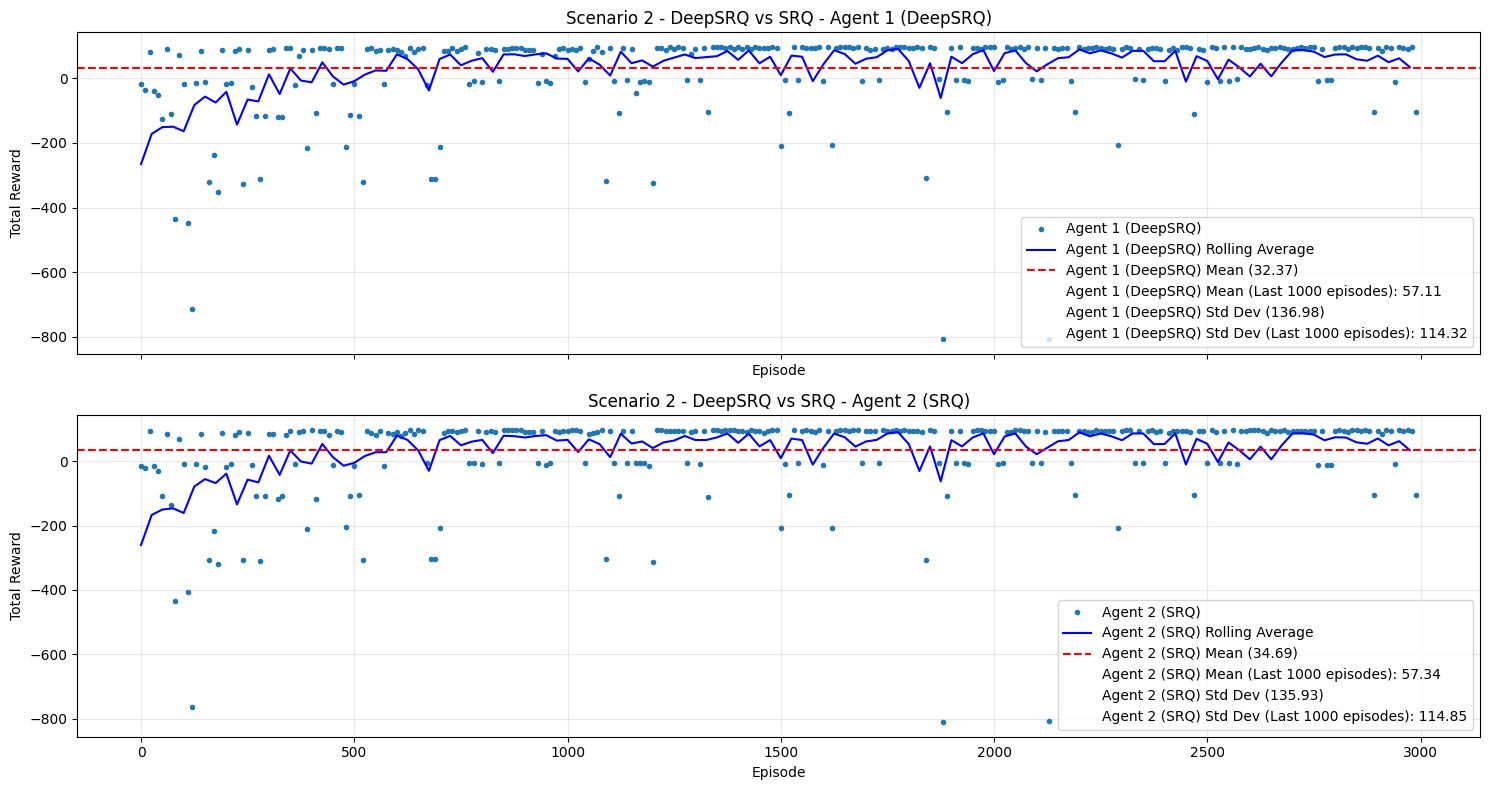

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario2/deep_srq_exponential_eps0.5_vs_srq_exponential_eps0.5_eps0.5_exponential_13126/training_stats.txt
Scenario 2 - DeepSRQ vs SRQ - deep_srq_exponential_eps0.5_vs_srq_exponential_eps0.5_eps0.5_exponential_13126
Wall clock: 3485.854s (58.10 min)
Episode time:   count=3000, mean=1.161165s (1161164.92 us), min=0.251331s, max=9.035842s, std=0.829094s
SRE solve time: count=578345, mean=0.005380s (5379.68 us), min=0.001441s, max=0.200583s, std=0.006807s
Backend solve:  count=3276075, mean=0.002622s (2621.71 us), min=0.000103s, max=0.234028s, std=0.005562s
  Agent 0 (deep_srq)
    SRE solve:  count=501267, mean=0.003200s (3199.99 us), min=0.001441s, max=0.074865s, std=0.002532s
    Backend:    count=501267, mean=0.014525s (14524.98 us), min=0.007158s, max=0.234028s, std=0.005769s
    Update:     count=37540, mean=0.042031s (42031.49 us), min=0.019863s, max=1.026498s, std=0.011609s
  Agent 1 (srq)
    SRE solve:  count=7707

scenario2: deep_srq_vs_srq: 100%|██████████| 3000/3000 [56:09<00:00,  1.12s/it] 


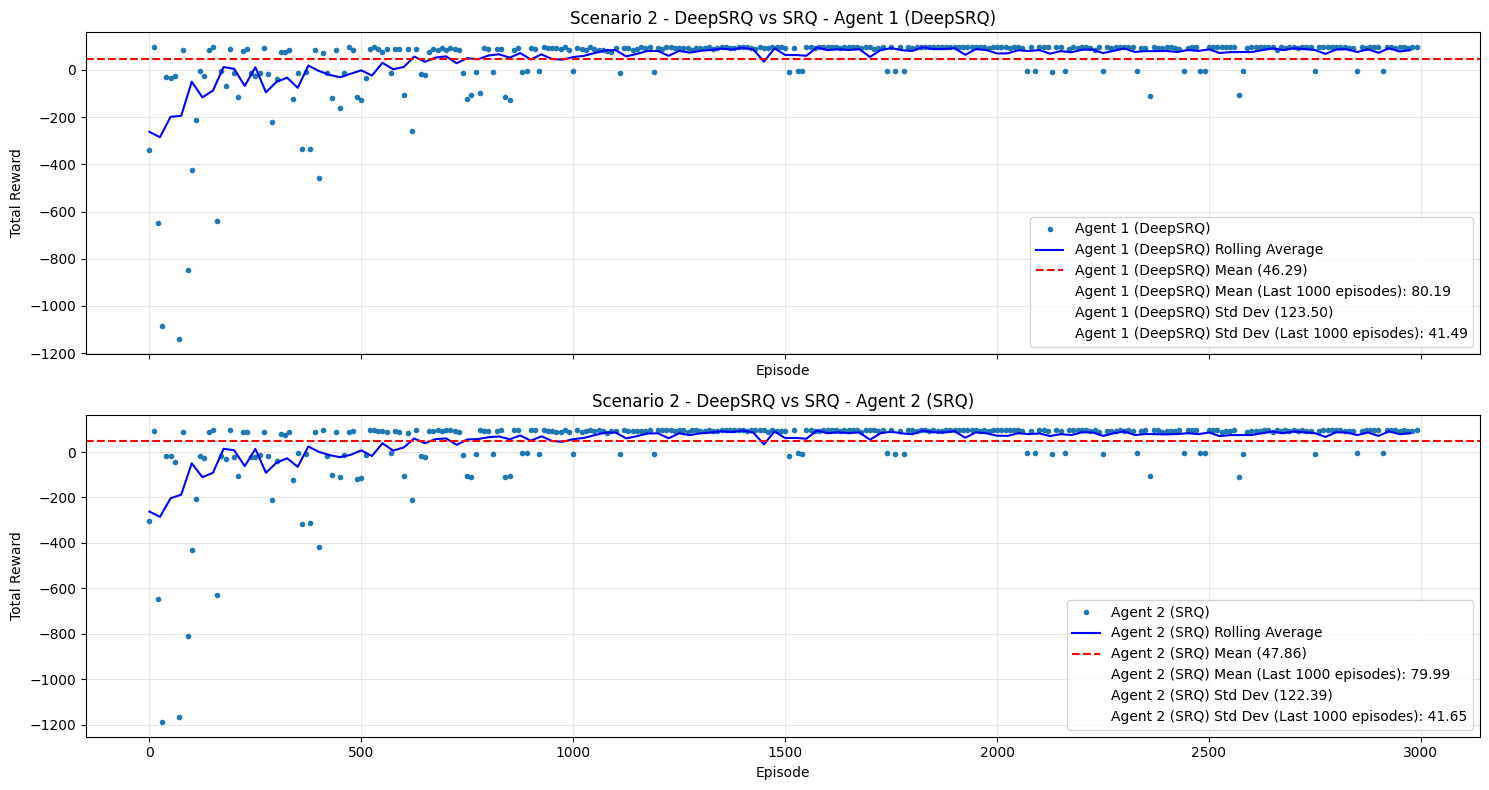

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario2/deep_srq_exponential_eps1_vs_srq_exponential_eps1_eps1_exponential_13127/training_stats.txt
Scenario 2 - DeepSRQ vs SRQ - deep_srq_exponential_eps1_vs_srq_exponential_eps1_eps1_exponential_13127
Wall clock: 3369.482s (56.16 min)
Episode time:   count=3000, mean=1.122330s (1122330.20 us), min=0.154601s, max=10.264981s, std=0.861090s
SRE solve time: count=547056, mean=0.005462s (5462.13 us), min=0.001327s, max=1.095062s, std=0.007657s
Backend solve:  count=3073286, mean=0.002672s (2671.95 us), min=0.000092s, max=1.127340s, std=0.005795s
  Agent 0 (deep_srq)
    SRE solve:  count=474878, mean=0.003141s (3141.06 us), min=0.001327s, max=1.095062s, std=0.003247s
    Backend:    count=474878, mean=0.014555s (14554.64 us), min=0.007070s, max=1.127340s, std=0.006936s
    Update:     count=35090, mean=0.042294s (42294.39 us), min=0.019652s, max=1.138611s, std=0.017752s
  Agent 1 (srq)
    SRE solve:  count=72178, mean=0.0

scenario2: deep_srq_vs_srq: 100%|██████████| 3000/3000 [58:03<00:00,  1.16s/it] 


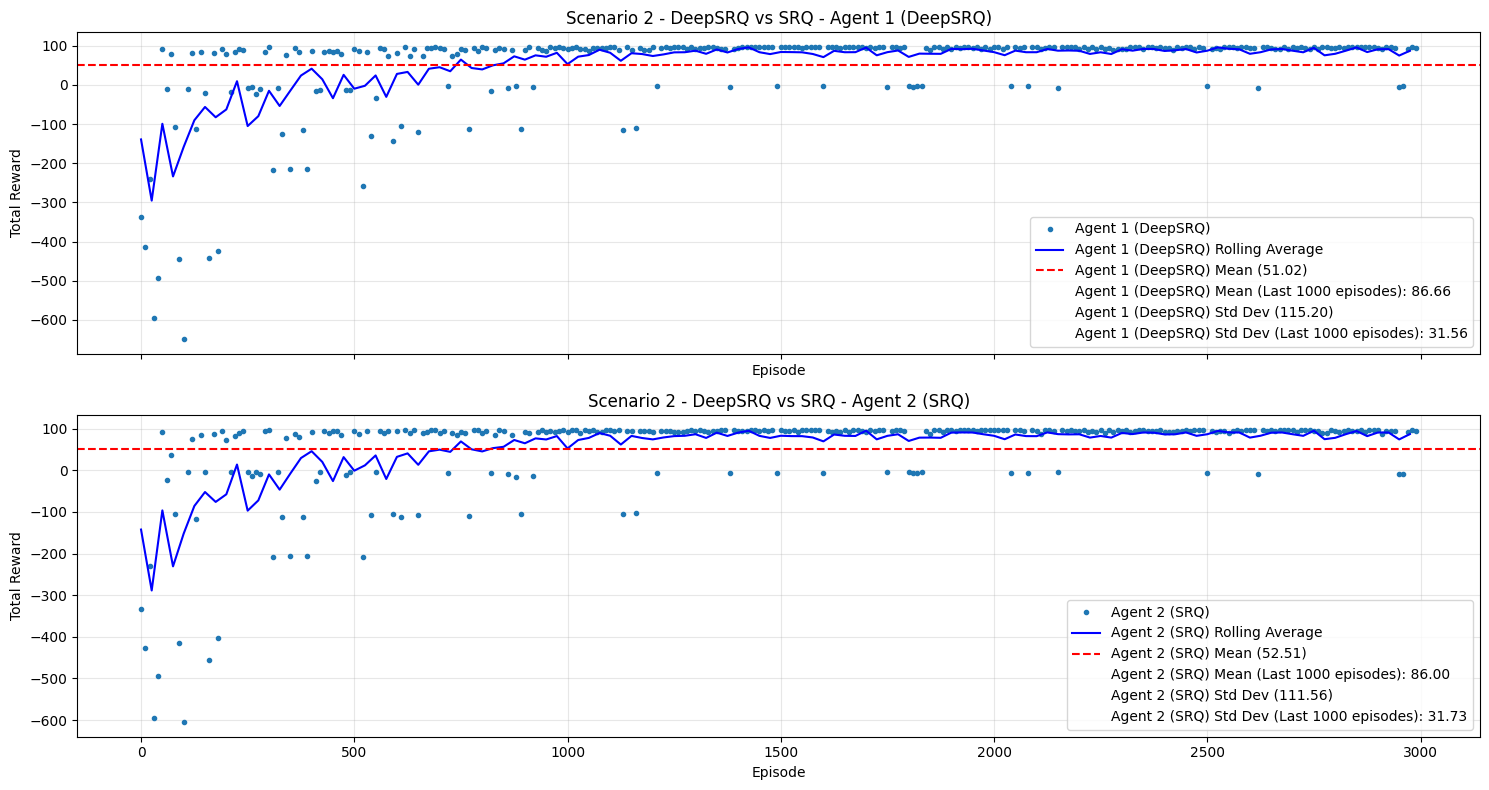

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario2/deep_srq_constant_eps0.25_vs_srq_constant_eps0.25_eps0.25_constant_13225/training_stats.txt
Scenario 2 - DeepSRQ vs SRQ - deep_srq_constant_eps0.25_vs_srq_constant_eps0.25_eps0.25_constant_13225
Wall clock: 3483.620s (58.06 min)
Episode time:   count=3000, mean=1.160316s (1160316.48 us), min=0.328724s, max=10.668081s, std=0.903686s
SRE solve time: count=519670, mean=0.006011s (6010.78 us), min=0.001340s, max=0.341661s, std=0.009821s
Backend solve:  count=2958330, mean=0.002751s (2750.58 us), min=0.000104s, max=1.963114s, std=0.006462s
  Agent 0 (deep_srq)
    SRE solve:  count=449994, mean=0.003447s (3447.25 us), min=0.001340s, max=0.244711s, std=0.004204s
    Backend:    count=449994, mean=0.015080s (15080.06 us), min=0.007235s, max=1.963114s, std=0.009575s
    Update:     count=33839, mean=0.044935s (44935.24 us), min=0.020335s, max=1.986837s, std=0.027801s
  Agent 1 (srq)
    SRE solve:  count=69676, mean=0.0

scenario2: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:03:35<00:00,  1.27s/it]


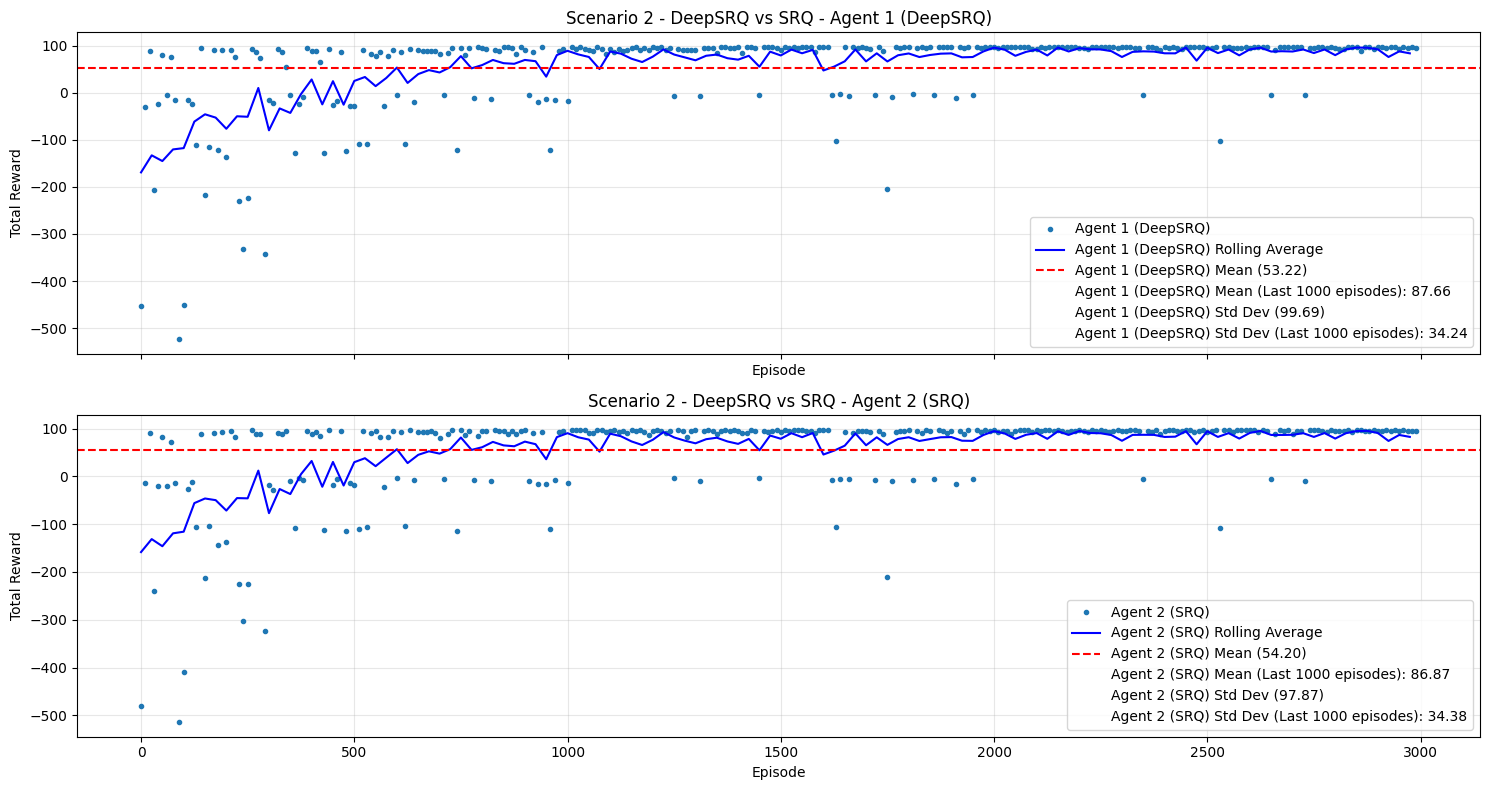

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario2/deep_srq_constant_eps0.5_vs_srq_constant_eps0.5_eps0.5_constant_13226/training_stats.txt
Scenario 2 - DeepSRQ vs SRQ - deep_srq_constant_eps0.5_vs_srq_constant_eps0.5_eps0.5_constant_13226
Wall clock: 3815.146s (63.59 min)
Episode time:   count=3000, mean=1.270874s (1270873.56 us), min=0.322723s, max=14.484227s, std=1.376899s
SRE solve time: count=539144, mean=0.006379s (6379.26 us), min=0.001378s, max=0.497472s, std=0.012674s
Backend solve:  count=3015884, mean=0.002848s (2848.15 us), min=0.000110s, max=0.629171s, std=0.006311s
  Agent 0 (deep_srq)
    SRE solve:  count=468380, mean=0.003428s (3427.53 us), min=0.001378s, max=0.228988s, std=0.003136s
    Backend:    count=468380, mean=0.014966s (14966.11 us), min=0.007248s, max=0.629171s, std=0.008656s
    Update:     count=34383, mean=0.047041s (47040.60 us), min=0.017791s, max=0.637220s, std=0.022291s
  Agent 1 (srq)
    SRE solve:  count=70764, mean=0.025916s

scenario2: deep_srq_vs_srq: 100%|██████████| 3000/3000 [58:59<00:00,  1.18s/it]  


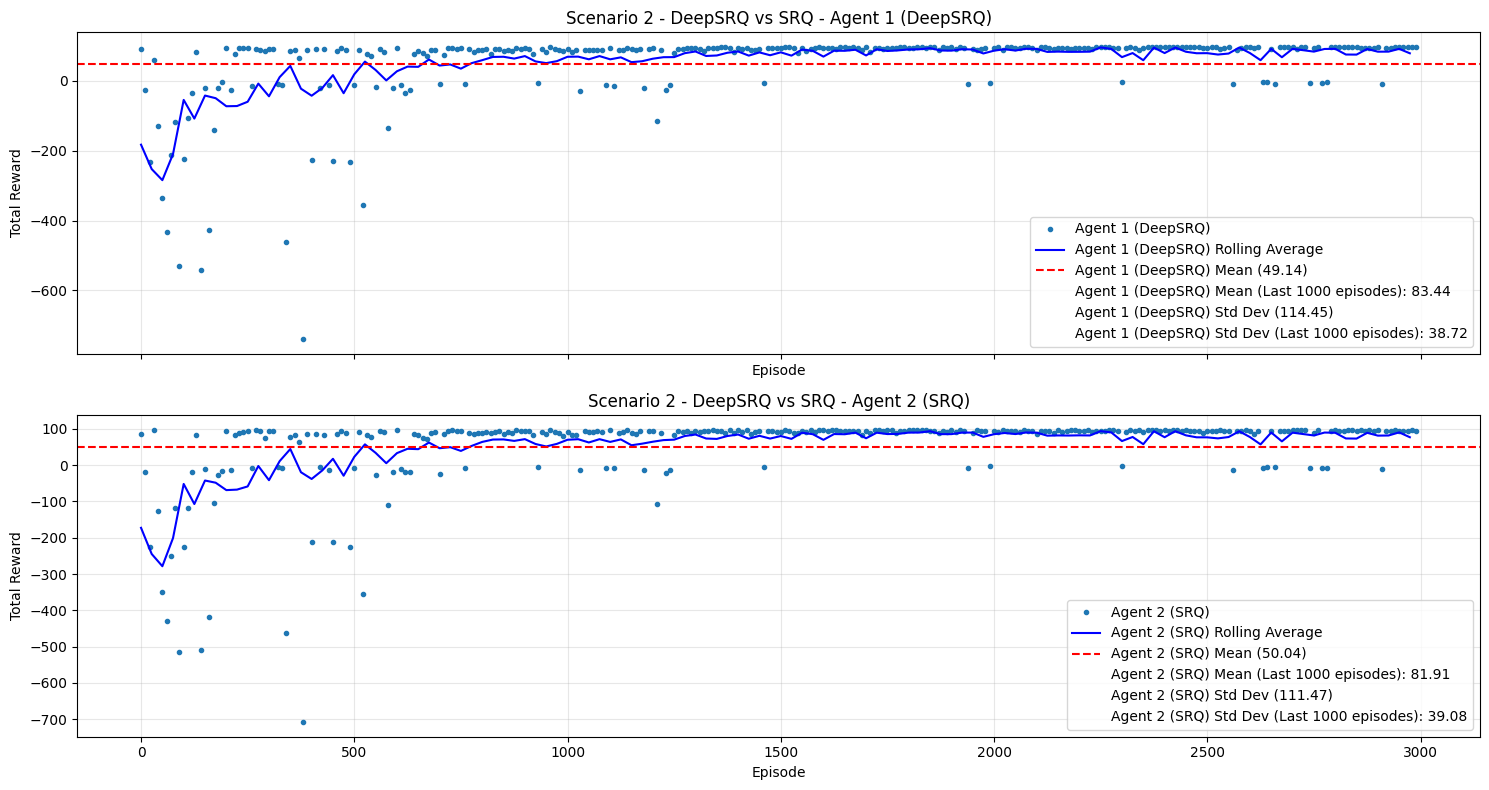

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario2/deep_srq_constant_eps1_vs_srq_constant_eps1_eps1_constant_13227/training_stats.txt
Scenario 2 - DeepSRQ vs SRQ - deep_srq_constant_eps1_vs_srq_constant_eps1_eps1_constant_13227
Wall clock: 3539.122s (58.99 min)
Episode time:   count=3000, mean=1.178895s (1178895.00 us), min=0.241945s, max=10.140741s, std=0.887020s
SRE solve time: count=602912, mean=0.005211s (5210.95 us), min=0.001374s, max=0.221364s, std=0.007441s
Backend solve:  count=3327172, mean=0.002577s (2577.21 us), min=0.000093s, max=0.270868s, std=0.005310s
  Agent 0 (deep_srq)
    SRE solve:  count=525076, mean=0.002924s (2924.29 us), min=0.001374s, max=0.076322s, std=0.002268s
    Backend:    count=525076, mean=0.013663s (13662.57 us), min=0.007164s, max=0.270868s, std=0.005508s
    Update:     count=37919, mean=0.041200s (41199.81 us), min=0.019439s, max=0.293363s, std=0.010065s
  Agent 1 (srq)
    SRE solve:  count=77836, mean=0.020637s (20636.61 u

scenario3: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:26:51<00:00,  1.74s/it]


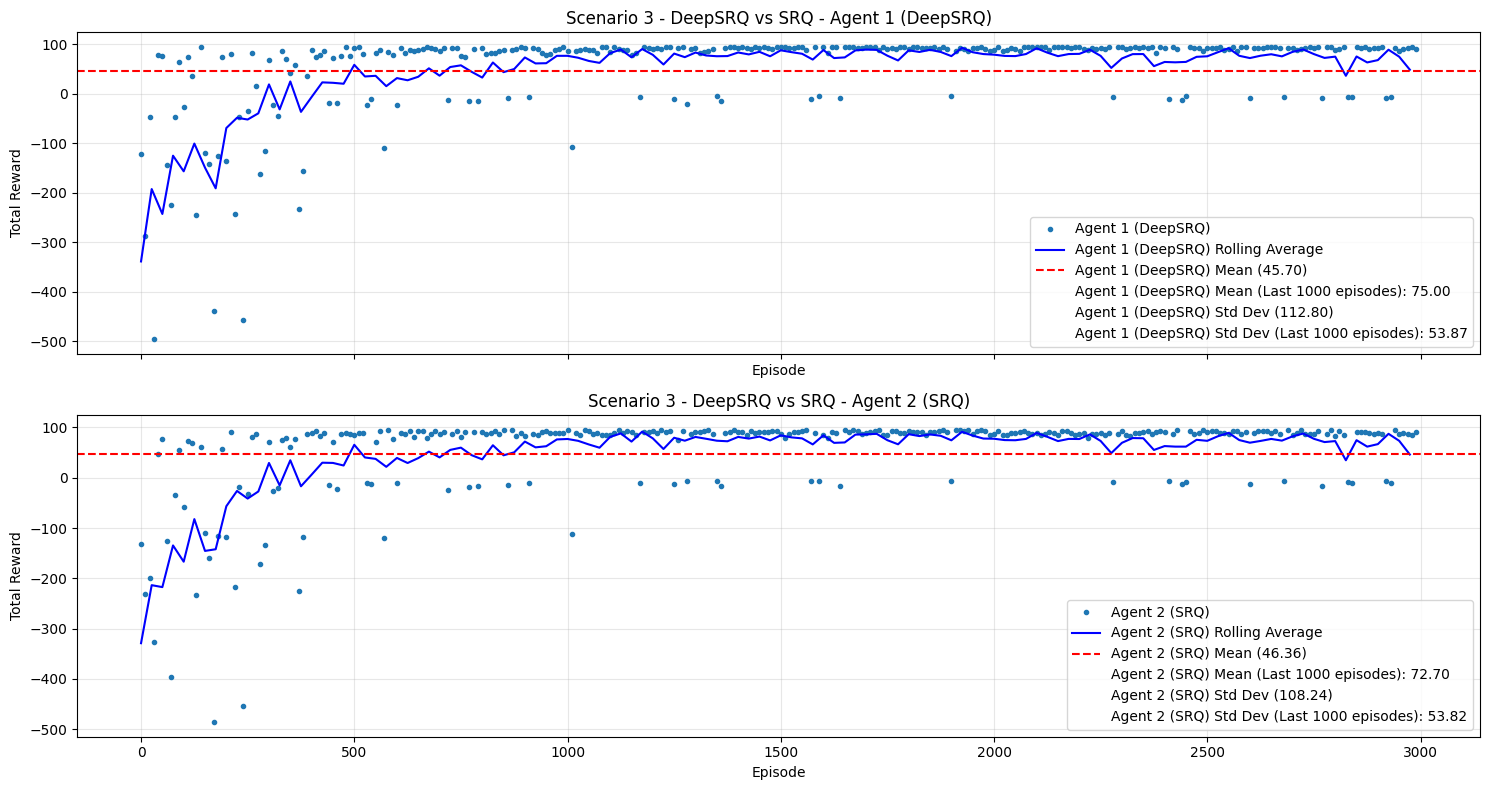

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario3/deep_srq_linear_eps0.25_vs_srq_linear_eps0.25_eps0.25_linear_14025/training_stats.txt
Scenario 3 - DeepSRQ vs SRQ - deep_srq_linear_eps0.25_vs_srq_linear_eps0.25_eps0.25_linear_14025
Wall clock: 5211.559s (86.86 min)
Episode time:   count=3000, mean=1.736354s (1736354.05 us), min=0.527191s, max=10.069084s, std=1.440242s
SRE solve time: count=943630, mean=0.004903s (4903.30 us), min=0.001255s, max=1.021121s, std=0.007225s
Backend solve:  count=4921380, mean=0.002745s (2745.44 us), min=0.000101s, max=1.094483s, std=0.005693s
  Agent 0 (deep_srq)
    SRE solve:  count=829980, mean=0.002847s (2846.75 us), min=0.001255s, max=1.021121s, std=0.002581s
    Backend:    count=829980, mean=0.013909s (13908.70 us), min=0.006851s, max=1.094483s, std=0.006319s
    Update:     count=55826, mean=0.043255s (43254.81 us), min=0.023890s, max=1.103449s, std=0.015766s
  Agent 1 (srq)
    SRE solve:  count=113650, mean=0.019922s (199

scenario3: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:36:06<00:00,  1.92s/it]  


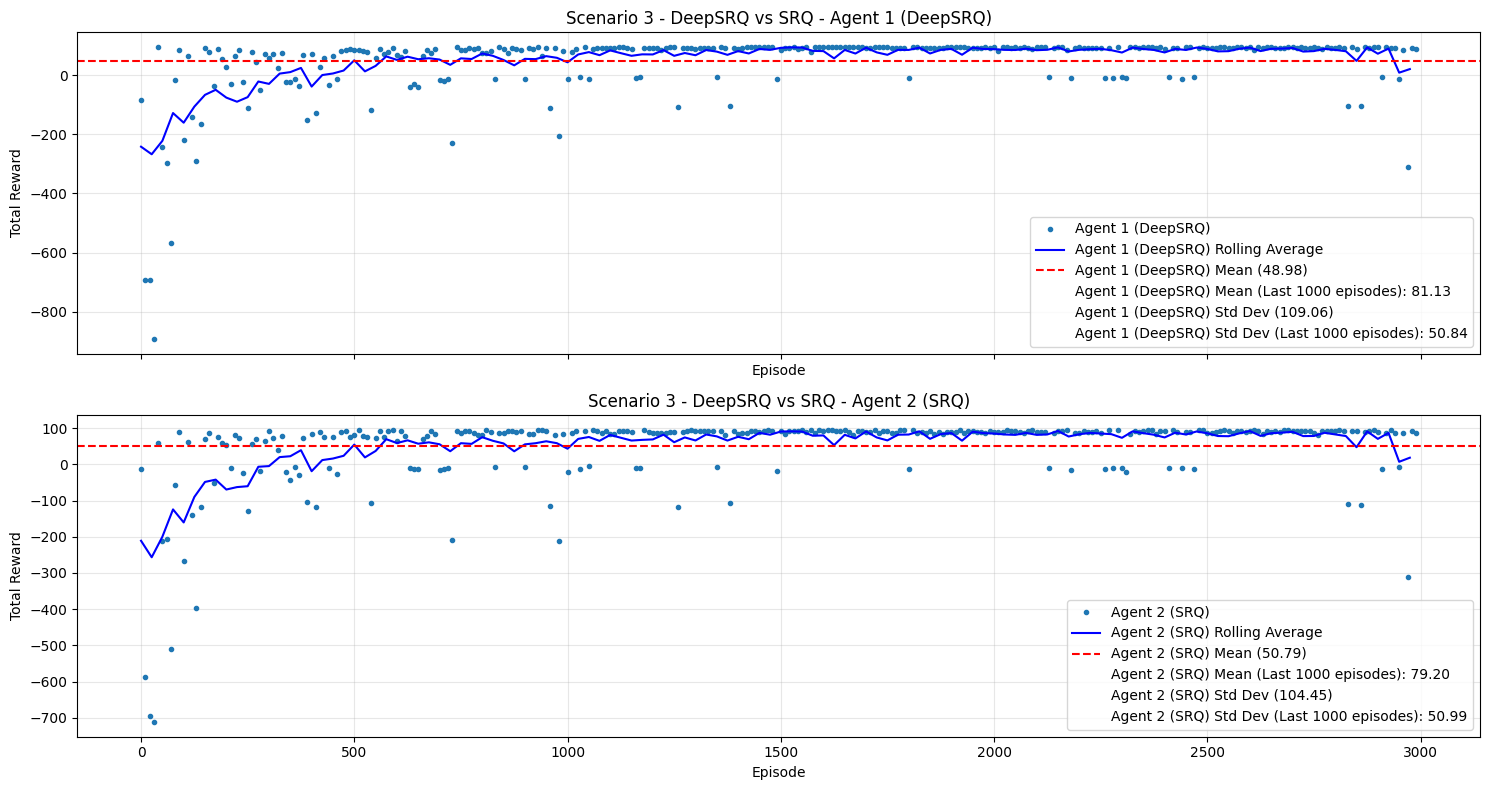

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario3/deep_srq_linear_eps0.5_vs_srq_linear_eps0.5_eps0.5_linear_14026/training_stats.txt
Scenario 3 - DeepSRQ vs SRQ - deep_srq_linear_eps0.5_vs_srq_linear_eps0.5_eps0.5_linear_14026
Wall clock: 5766.734s (96.11 min)
Episode time:   count=3000, mean=1.921379s (1921379.15 us), min=0.432006s, max=17.687859s, std=1.709615s
SRE solve time: count=949522, mean=0.005455s (5454.93 us), min=0.001279s, max=1.090112s, std=0.009003s
Backend solve:  count=4960382, mean=0.003008s (3007.91 us), min=0.000108s, max=1.160139s, std=0.006379s
  Agent 0 (deep_srq)
    SRE solve:  count=834926, mean=0.003185s (3184.64 us), min=0.001279s, max=1.090112s, std=0.002977s
    Backend:    count=834926, mean=0.015275s (15275.25 us), min=0.006599s, max=1.160139s, std=0.007532s
    Update:     count=56299, mean=0.047381s (47381.44 us), min=0.024762s, max=1.187925s, std=0.018743s
  Agent 1 (srq)
    SRE solve:  count=114596, mean=0.021996s (21995.87 

scenario3: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:34:37<00:00,  1.89s/it]


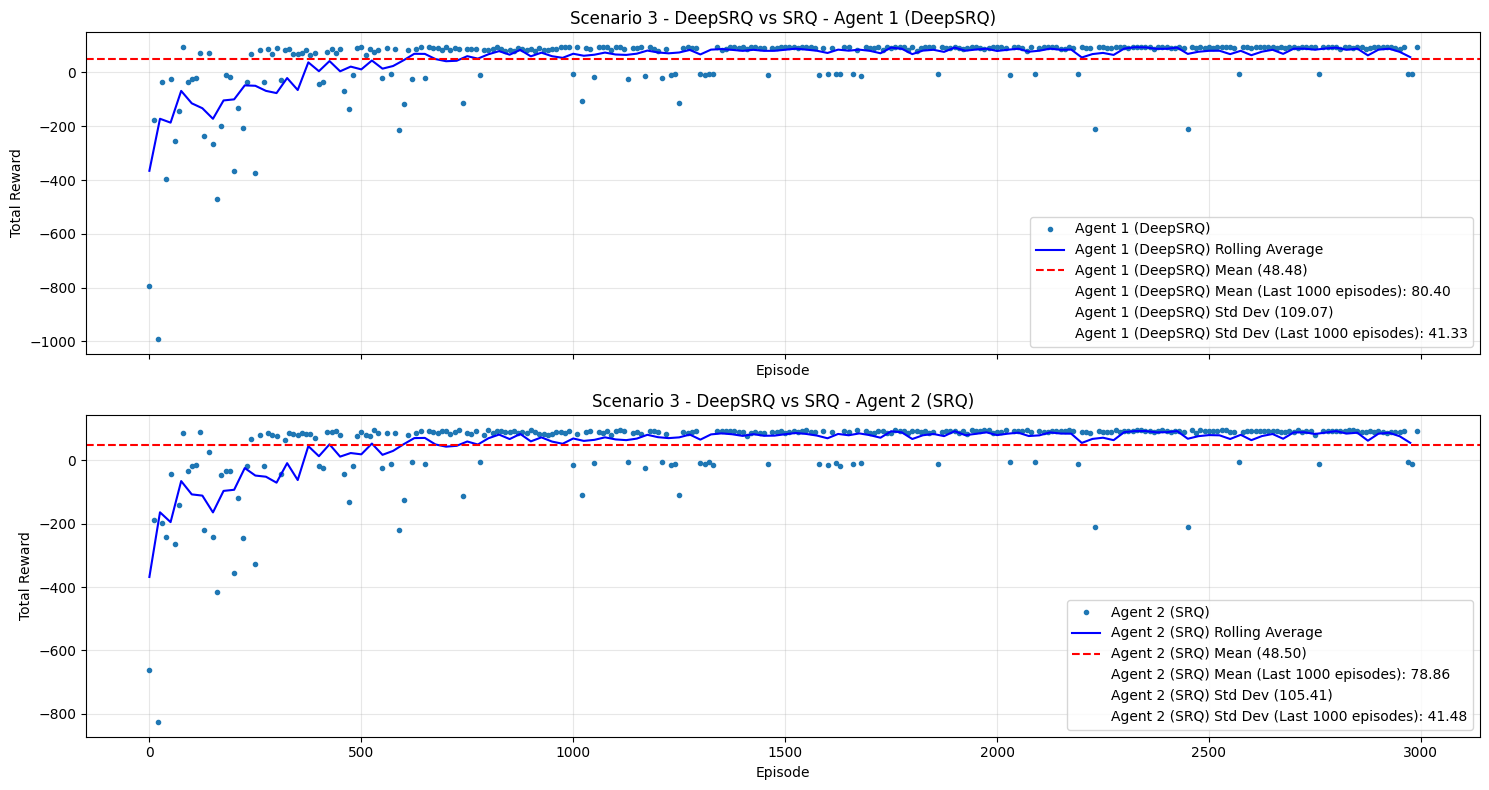

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario3/deep_srq_linear_eps1_vs_srq_linear_eps1_eps1_linear_14027/training_stats.txt
Scenario 3 - DeepSRQ vs SRQ - deep_srq_linear_eps1_vs_srq_linear_eps1_eps1_linear_14027
Wall clock: 5639.813s (94.00 min)
Episode time:   count=3000, mean=1.879085s (1879085.24 us), min=0.565954s, max=10.360758s, std=1.434928s
SRE solve time: count=940511, mean=0.005418s (5418.22 us), min=0.001368s, max=0.259301s, std=0.008228s
Backend solve:  count=4869611, mean=0.002989s (2989.41 us), min=0.000093s, max=0.347218s, std=0.006029s
  Agent 0 (deep_srq)
    SRE solve:  count=828251, mean=0.003073s (3072.81 us), min=0.001368s, max=0.259301s, std=0.002593s
    Backend:    count=828251, mean=0.014907s (14907.22 us), min=0.006909s, max=0.347218s, std=0.006256s
    Update:     count=55131, mean=0.045923s (45923.22 us), min=0.023861s, max=0.358869s, std=0.011445s
  Agent 1 (srq)
    SRE solve:  count=112260, mean=0.022723s (22722.54 us), min=0.0

scenario3: deep_srq_vs_srq:  51%|█████     | 1534/3000 [1:15:56<31:38,  1.30s/it]  

In [ ]:
deep_srq_vs_tabular_srq_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "srq"),
    case_slug="deep_srq_vs_tabular_srq",
    case_seed_offset=10_000,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_tabular_srq_manifest.txt",
    deep_srq_vs_tabular_srq_results,
)


## Deep SRQ vs Nash Q

In [ ]:
deep_srq_vs_nash_q_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "nashq"),
    case_slug="deep_srq_vs_nash_q",
    case_seed_offset=20_000,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_nash_q_manifest.txt",
    deep_srq_vs_nash_q_results,
)
